# Illocutionary Intent LM — CMA Space + Prophetic Mediator

**Architecture:** 6-head panel (3 neural + 3 sklearn) → shared CMA space → Prophetic Mediator → Gate → Vocab  
**CMA Space:** Heads contribute structural information via set-algebra, not vocab predictions  
**Prophet:** Draws learned decision boundary between neural/classical territories. Forces consensus only in contested zones where disagreement is violent. Preserves paradigm-specific signal elsewhere.  
**Gates:** Dumb / Strong / God — the independent variable  
**Losses:** NLL + CMA structured disagreement + Prophet (boundary + territory + overactivation) + gate entropy + aux NLL

**Backbone:** Block Attention Residuals (Chen et al., 2026)  
**Classical heads:** PolarQuant hidden → sklearn (no TF-IDF)

In [1]:
%%capture
!pip install gdown

In [2]:
import gdown

file_id = '1gZHSDaEFWys1XnXH8H2snuOvMsm_CucX'
output_path = f'/content/checkpoint_god_final.pt'

try:
    gdown.download(id=file_id, output=output_path, quiet=False, fuzzy=True)
    print(f"File downloaded to: {output_path}")
except Exception as e:
    print(f"Error downloading file: {e}")
    print("Please ensure the file is publicly accessible or grant appropriate permissions.")

Downloading...
From (original): https://drive.google.com/uc?id=1gZHSDaEFWys1XnXH8H2snuOvMsm_CucX
From (redirected): https://drive.google.com/uc?id=1gZHSDaEFWys1XnXH8H2snuOvMsm_CucX&confirm=t&uuid=c601b5aa-8f26-4d0b-80c5-102b81d770f6
To: /content/checkpoint_god_final.pt
100%|██████████| 488M/488M [00:02<00:00, 220MB/s]


File downloaded to: /content/checkpoint_god_final.pt


In [3]:
!pip install datasets tokenizers scikit-learn matplotlib -q

In [4]:
import os

# ══════════════════════════════════════════════════════════════════════
# Google Drive Mount + Checkpoint Directory
# ══════════════════════════════════════════════════════════════════════

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CHECKPOINT_DIR = "/content/drive/MyDrive/IllocutionaryIntentLM_checkpoints"
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    print(f"✅ Drive mounted. Checkpoints → {CHECKPOINT_DIR}")
except Exception as e:
    CHECKPOINT_DIR = "/content" if os.path.exists("/content") else "."
    print(f"⚠ Drive mount failed ({e}), using local: {CHECKPOINT_DIR}")

_test_path = os.path.join(CHECKPOINT_DIR, ".write_test")
try:
    with open(_test_path, "w") as f:
        f.write("ok")
    os.remove(_test_path)
    print(f"✅ Write test passed")
except Exception as e:
    print(f"❌ Cannot write to {CHECKPOINT_DIR}: {e}")
    CHECKPOINT_DIR = "/content" if os.path.exists("/content") else "."
    print(f"   Falling back to {CHECKPOINT_DIR}")

# ══════════════════════════════════════════════════════════════════════
# Illocutionary Intent LM — CMA (Cross-Method Attribution) Space
# ══════════════════════════════════════════════════════════════════════
#
# ARCHITECTURE CHANGE FROM v1:
#   Heads no longer predict vocab logits independently.
#   All 6 heads project into a shared CMA space (d_model dims).
#   Set-algebra attribution structure (intersection, symmetric
#   differences, cross-paradigm overlap) is computed IN that space
#   as explicit tensor operations. The gate operates on agreement/
#   disagreement *patterns*, not prediction quality.
#
#   A single learned projection maps CMA consensus → vocab.
#
# WHY:
#   In v1, the gate correctly learned to ignore sklearn heads because
#   they couldn't compete on NLL over 16K vocab. This killed the
#   cross-paradigm disagreement structure — the entire point.
#   CMA space forces all heads onto equal footing: they contribute
#   *structural* information, not predictions. The gate's job is to
#   maintain structured disagreement, not pick the best predictor.
#
# HEADS (unchanged architectures, new output):
#   1. BiLSTM + Bahdanau Attention     → CMA projection
#   2. 2×BiLSTM mean-pool              → CMA projection
#   3. sklearn LR on PolarQuant        → CMA projection
#   4. sklearn RF on PolarQuant        → CMA projection
#   5. sklearn NB on PolarQuant        → CMA projection
#   6. Sparsemax BiLSTM                → CMA projection
#
# GATES (the independent variable):
#   A. Dumb Gate — Linear(d→d/2→6), no self-modelling capacity
#   B. Strong Gate — Full attention block + Linear(d→6)
#   C. God Gate — Learns from A+B disagreement, selects which to trust
#
# LOSSES:
#   1. NLL on consensus → vocab (language modelling)
#   2. Structured disagreement loss (penalise both collapse and chaos)
#   3. Gate entropy bonus (prevent gate collapse)
#   4. Aux NLL on neural heads (keep them learning)
#   5. Alpha variance bonus (god gate must learn to switch)
#
# BACKBONE: Block Attention Residuals (Chen et al., 2026)
# CLASSICAL HEADS: PolarQuant hidden → sklearn (no TF-IDF anywhere)
#
# ══════════════════════════════════════════════════════════════════════

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
from typing import Literal
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB


# ── Config ──────────────────────────────────────────────────────────

@dataclass
class IntentLMConfig:
    vocab_size: int = 16384
    max_seq_len: int = 256
    d_model: int = 256
    n_heads: int = 8
    n_layers: int = 4
    d_ff: int = 1024
    # PolarQuant
    polar_n_angles: int = 128
    polar_top_k: int = 64
    # BiLSTM heads
    lstm_units: int = 128
    lstm_layers: int = 2
    attn_units: int = 128
    # Block AttnRes
    attn_res_block_size: int = 2
    # Panel
    n_panel_heads: int = 6
    # Independent features (TF-IDF / BM25)
    tfidf_window_size: int = 32
    # CMA space
    d_cma: int = 256              # CMA space dimensionality (= d_model)
    # Gate — the independent variable
    gate_type: Literal["dumb", "strong", "god"] = "god"
    # Activations
    lossy_alpha: float = 0.01
    lossy_noise_std: float = 0.05
    dropout: float = 0.1
    # Regularisation
    gate_entropy_weight: float = 0.1
    aux_loss_weight: float = 0.1
    # CMA losses
    cma_disagree_weight: float = 0.05   # structured disagreement
    cma_collapse_weight: float = 0.1    # anti-collapse
    cma_chaos_weight: float = 0.05      # anti-chaos
    # Prophetic Mediator
    prophet_enabled: bool = True
    prophet_violence_threshold: float = 0.5
    prophet_temperature: float = 0.1
    prophet_margin: float = 0.3         # boundary contested zone width
    prophet_boundary_weight: float = 0.1
    prophet_territory_weight: float = 0.05
    # Training
    device: str = "cuda"
    seed: int = 42


# ── Lossy-ReLU ──────────────────────────────────────────────────────

class LossyReLU(nn.Module):
    def __init__(self, alpha=0.01, noise_std=0.05):
        super().__init__()
        self.alpha = alpha
        self.noise_std = noise_std

    def forward(self, x):
        out = F.leaky_relu(x, negative_slope=self.alpha)
        if self.training and self.noise_std > 0:
            out = out + torch.randn_like(out) * self.noise_std
        return out


# ── PolarQuant Projection ──────────────────────────────────────────

class PolarQuantProjection(nn.Module):
    def __init__(self, d_model, n_angles=64, top_k=32):
        super().__init__()
        self.d_model = d_model
        self.n_angles = n_angles
        self.top_k = min(top_k, d_model // 2)

        Q, _ = torch.linalg.qr(torch.randn(d_model, d_model))
        self.register_buffer('rotation', Q)

        self.proj_back = nn.Linear(2 * self.top_k, d_model)
        self.activation = LossyReLU()
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        residual = x
        rotated = torch.matmul(x, self.rotation)
        d_pairs = self.d_model // 2
        pairs = rotated[..., :2 * d_pairs].reshape(*x.shape[:-1], d_pairs, 2)
        radii = torch.norm(pairs, dim=-1)
        angles = torch.atan2(pairs[..., 1], pairs[..., 0])

        angle_bins = ((angles + math.pi) / (2 * math.pi) * self.n_angles)
        angle_quant = angle_bins.round()
        angle_quant = angle_bins + (angle_quant - angle_bins).detach()

        top_radii, top_idx = torch.topk(radii, self.top_k, dim=-1)
        top_angles = torch.gather(angle_quant, -1, top_idx)
        top_angles = top_angles / self.n_angles
        top_radii = top_radii / (top_radii.max(dim=-1, keepdim=True).values + 1e-8)

        polar_features = torch.cat([top_angles, top_radii], dim=-1)
        projected = self.activation(self.proj_back(polar_features))
        return self.norm(projected + residual)

    def to_sparse_features(self, x):
        rotated = torch.matmul(x, self.rotation)
        d_pairs = self.d_model // 2
        pairs = rotated[..., :2 * d_pairs].reshape(*x.shape[:-1], d_pairs, 2)
        radii = torch.norm(pairs, dim=-1)
        angles = torch.atan2(pairs[..., 1], pairs[..., 0])

        angle_bins = ((angles + math.pi) / (2 * math.pi) * self.n_angles)
        angle_quant = angle_bins.round()

        top_radii, top_idx = torch.topk(radii, self.top_k, dim=-1)
        top_angles = torch.gather(angle_quant, -1, top_idx)
        top_angles = top_angles / self.n_angles
        top_radii = top_radii / (top_radii.max(dim=-1, keepdim=True).values + 1e-8)
        return torch.cat([top_angles, top_radii], dim=-1)


# ── Causal Self-Attention ───────────────────────────────────────────

Mounted at /content/drive
✅ Drive mounted. Checkpoints → /content/drive/MyDrive/IllocutionaryIntentLM_checkpoints
✅ Write test passed


In [5]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, max_seq_len, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            'causal_mask',
            torch.tril(torch.ones(max_seq_len, max_seq_len))
                 .unsqueeze(0).unsqueeze(0))

    def forward(self, x, kv_cache=None):
        B, S, D = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, S, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, S, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, S, self.n_heads, self.head_dim).transpose(1, 2)

        if kv_cache is not None:
            k_cached, v_cached = kv_cache
            k = torch.cat([k_cached, k], dim=2)
            v = torch.cat([v_cached, v], dim=2)

        new_cache = (k, v)
        T = k.shape[2]

        scale = math.sqrt(self.head_dim)
        attn = torch.matmul(q, k.transpose(-2, -1)) / scale
        if S == T:
            attn = attn.masked_fill(
                self.causal_mask[:, :, :S, :S] == 0, float('-inf'))
        else:
            mask = torch.ones(S, T, device=x.device, dtype=torch.bool)
            mask = torch.tril(mask, diagonal=T - S)
            attn = attn.masked_fill(~mask.unsqueeze(0).unsqueeze(0), float('-inf'))

        attn_weights = F.softmax(attn, dim=-1)
        attn_weights = self.dropout(attn_weights)
        out = torch.matmul(attn_weights, v)
        out = out.transpose(1, 2).contiguous().view(B, S, D)
        return self.out_proj(out), attn_weights, new_cache


# ── Block Attention Residuals (Chen et al., 2026) ──────────────────

class BlockAttnRes(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.query = nn.Parameter(torch.zeros(d_model))
        self.norm = nn.LayerNorm(d_model)

    def forward(self, blocks, partial_block):
        all_reps = blocks + [partial_block]
        V = torch.stack(all_reps, dim=0)
        K = self.norm(V)
        logits = torch.einsum('d, n b t d -> n b t', self.query, K)
        alpha = logits.softmax(dim=0)
        return torch.einsum('n b t, n b t d -> b t d', alpha, V)


class TransformerBlockAttnRes(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, max_seq_len,
                 dropout=0.1, lossy_alpha=0.01, lossy_noise=0.05,
                 polar_n_angles=128, polar_top_k=64):
        super().__init__()
        self.attn_res = BlockAttnRes(d_model)
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, max_seq_len, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            LossyReLU(lossy_alpha, lossy_noise),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )
        self.polar = PolarQuantProjection(d_model, polar_n_angles, polar_top_k)

    def forward(self, x, blocks, kv_cache=None):
        h = self.attn_res(blocks, x)
        attn_out, attn_w, new_cache = self.attn(self.ln1(h), kv_cache=kv_cache)
        x = h + attn_out
        x = x + self.ffn(self.ln2(x))
        x = self.polar(x)
        return x, attn_w, new_cache

In [6]:
# ══════════════════════════════════════════════════════════════════════
# CMA SPACE — Cross-Method Attribution Communication Layer
# ══════════════════════════════════════════════════════════════════════
#
# Every head projects into this shared space. The set-algebra
# operations (intersection, symmetric difference, cross-paradigm
# overlap) are computed here as differentiable tensor ops.
#
# KEY INSIGHT: Heads don't need to agree on WHAT token comes next.
# They need to agree on WHERE structure exists. CMA space captures
# per-token structural salience, not prediction.
#
# Set operations are approximated via cosine similarity:
#   - High cos(h_i, h_j) at token t → both heads "see" structure there
#     → token t is in the soft intersection
#   - High ||h_i||, low cos(h_i, h_j) → head i sees structure that
#     j doesn't → token t is in the soft symmetric difference
# ══════════════════════════════════════════════════════════════════════

class CMASpace(nn.Module):
    """
    Cross-Method Attribution space.

    Takes d_cma projections from all 6 heads, computes:
      - Pairwise agreement matrix (soft intersection)
      - Per-head salience (norm in CMA space)
      - Cross-paradigm agreement (neural vs classical consensus)
      - Structured disagreement features for the gate

    Returns:
      - consensus: weighted combination in CMA space [B, S, d_cma]
      - set_algebra: dict of attribution structure tensors
    """
    def __init__(self, config: IntentLMConfig):
        super().__init__()
        self.config = config
        self.n_heads = config.n_panel_heads
        self.d_cma = config.d_cma

        # Normalisation per head in CMA space
        self.head_norms = nn.ModuleList([
            nn.LayerNorm(config.d_cma) for _ in range(config.n_panel_heads)
        ])

        # Consensus → vocab projection (the ONLY path to token prediction)
        self.consensus_to_vocab = nn.Sequential(
            nn.Linear(config.d_cma, config.d_ff),
            LossyReLU(config.lossy_alpha, 0.0),
            nn.Dropout(config.dropout),
            nn.Linear(config.d_ff, config.vocab_size),
        )

        # Neural head indices: 0=bilstm_attn, 1=bilstm_pool, 5=sparsemax
        # Classical head indices: 2=lr, 3=rf, 4=nb
        self.neural_idx = [0, 1, 5]
        self.classical_idx = [2, 3, 4]

    def compute_set_algebra(self, head_cma_list):
        """
        Differentiable set-algebra in CMA space.

        head_cma_list: list of 6 × [B, S, d_cma] (normalised)

        Returns dict with:
          - pairwise_agreement: [B, S, 6, 6] cosine similarities
          - per_head_salience: [B, S, 6] norms (how "loud" each head is)
          - neural_consensus: [B, S, d_cma] mean of neural heads
          - classical_consensus: [B, S, d_cma] mean of classical heads
          - cross_paradigm_agreement: [B, S] cosine(neural, classical)
          - intersection_strength: [B, S] mean pairwise agreement
          - disagreement_structure: [B, S] variance of pairwise agreements
        """
        B, S, D = head_cma_list[0].shape

        # Stack all heads: [B, S, 6, d_cma]
        stacked = torch.stack(head_cma_list, dim=2)

        # Per-head salience: how much each head "activates" per token
        # [B, S, 6]
        salience = torch.norm(stacked, dim=-1)

        # Normalise for cosine similarity
        stacked_norm = F.normalize(stacked, dim=-1)  # [B, S, 6, d_cma]

        # Pairwise agreement matrix: [B, S, 6, 6]
        # cos(h_i, h_j) for all pairs — soft intersection measure
        pairwise = torch.matmul(
            stacked_norm, stacked_norm.transpose(-1, -2))  # [B, S, 6, 6]

        # Neural consensus: mean of neural head CMA vectors
        neural_vecs = torch.stack(
            [head_cma_list[i] for i in self.neural_idx], dim=2)
        neural_consensus = neural_vecs.mean(dim=2)  # [B, S, d_cma]

        # Classical consensus: mean of classical head CMA vectors
        classical_vecs = torch.stack(
            [head_cma_list[i] for i in self.classical_idx], dim=2)
        classical_consensus = classical_vecs.mean(dim=2)  # [B, S, d_cma]

        # Cross-paradigm agreement: cosine(neural_mean, classical_mean)
        cross_agreement = F.cosine_similarity(
            neural_consensus, classical_consensus, dim=-1)  # [B, S]

        # Intersection strength: mean of upper triangle of pairwise
        mask = torch.triu(torch.ones(6, 6, device=stacked.device), diagonal=1)
        mask = mask.bool()
        # [B, S, 15] (15 = 6 choose 2)
        upper_vals = pairwise[:, :, mask]
        intersection_strength = upper_vals.mean(dim=-1)  # [B, S]

        # Disagreement structure: variance of pairwise agreements
        # High variance = STRUCTURED disagreement (some agree, some don't)
        # Low variance + high mean = collapse (all agree)
        # Low variance + low mean = chaos (all disagree randomly)
        disagreement_structure = upper_vals.var(dim=-1)  # [B, S]

        return {
            'pairwise_agreement': pairwise,
            'per_head_salience': salience,
            'neural_consensus': neural_consensus,
            'classical_consensus': classical_consensus,
            'cross_paradigm_agreement': cross_agreement,
            'intersection_strength': intersection_strength,
            'disagreement_structure': disagreement_structure,
            'stacked': stacked,  # raw CMA vectors for gate
        }

    def forward(self, head_cma_list, gate_weights):
        """
        head_cma_list: list of 6 × [B, S, d_cma]
        gate_weights: [B, S, 6] from the gate

        Returns:
          - logprobs: [B, S, V] consensus → vocab log-probs
          - set_algebra: dict of attribution structure
        """
        # Normalise each head's CMA projection
        normed = [self.head_norms[i](h) for i, h in enumerate(head_cma_list)]

        # Compute set algebra
        set_algebra = self.compute_set_algebra(normed)

        # Weighted consensus in CMA space
        # gate_weights: [B, S, 6] → [B, S, 6, 1]
        stacked = torch.stack(normed, dim=2)  # [B, S, 6, d_cma]
        weighted = gate_weights.unsqueeze(-1) * stacked  # [B, S, 6, d_cma]
        consensus = weighted.sum(dim=2)  # [B, S, d_cma]

        # Project to vocab
        logits = self.consensus_to_vocab(consensus)
        logprobs = F.log_softmax(logits, dim=-1)

        return logprobs, set_algebra


# ══════════════════════════════════════════════════════════════════════
# CMA LOSS — Structured Disagreement Objective
# ══════════════════════════════════════════════════════════════════════

class CMALoss(nn.Module):
    """
    The loss that makes CMA space work.

    Three competing pressures:
      1. ANTI-COLLAPSE: penalise intersection_strength → 1.0
         (all heads agree = no attribution signal)
      2. ANTI-CHAOS: penalise intersection_strength → 0.0
         (no agreement = noise, not structure)
      3. PRO-STRUCTURE: reward high disagreement_structure variance
         (some pairs agree, some don't = structured attribution)

    Plus: reward cross-paradigm agreement being neither 0 nor 1.
    The sweet spot is partial, patterned cross-paradigm alignment.
    """
    def __init__(self, config: IntentLMConfig):
        super().__init__()
        self.collapse_weight = config.cma_collapse_weight
        self.chaos_weight = config.cma_chaos_weight
        self.disagree_weight = config.cma_disagree_weight
        # Target intersection strength: partial agreement
        self.target_intersection = 0.4  # neither 0 nor 1

    def forward(self, set_algebra):
        """
        set_algebra: dict from CMASpace.compute_set_algebra()
        Returns: scalar loss, dict of component values
        """
        intersection = set_algebra['intersection_strength']  # [B, S]
        disagree = set_algebra['disagreement_structure']      # [B, S]
        cross = set_algebra['cross_paradigm_agreement']       # [B, S]

        # Anti-collapse: penalise intersection near 1
        # L_collapse = mean(max(0, intersection - target)^2)
        collapse_loss = torch.clamp(
            intersection - self.target_intersection, min=0).pow(2).mean()

        # Anti-chaos: penalise intersection near 0
        # L_chaos = mean(max(0, target - intersection)^2)
        chaos_loss = torch.clamp(
            self.target_intersection - intersection, min=0).pow(2).mean()

        # Pro-structure: reward high variance in pairwise agreements
        # Negative because we WANT high variance (structured disagreement)
        structure_reward = -disagree.mean()

        # Cross-paradigm: penalise extremes (0 or 1)
        # Quadratic penalty centred at 0.5
        cross_penalty = (cross - 0.5).pow(2).mean()

        total = (self.collapse_weight * collapse_loss
                 + self.chaos_weight * chaos_loss
                 + self.disagree_weight * structure_reward
                 + 0.05 * cross_penalty)

        components = {
            'cma_collapse_loss': collapse_loss.item(),
            'cma_chaos_loss': chaos_loss.item(),
            'cma_structure_reward': -structure_reward.item(),
            'cma_cross_penalty': cross_penalty.item(),
            'cma_intersection_mean': intersection.mean().item(),
            'cma_disagree_var_mean': disagree.mean().item(),
            'cma_cross_mean': cross.mean().item(),
        }

        return total, components


# ══════════════════════════════════════════════════════════════════════
# PROPHETIC MEDIATOR — Boundary-Learning Disagreement Negotiator
# ══════════════════════════════════════════════════════════════════════
#
# The prophet sees A\R (neural-exclusive) and R\A (classical-exclusive)
# in CMA space. It does NOT predict or override — it draws a learned
# decision boundary that defines:
#   - Neural territory (positive side of boundary)
#   - Classical territory (negative side)
#   - Contested zone (near zero — where consensus must happen)
#
# Heads in the contested zone are pulled toward agreement.
# Heads in their own territory stay free to maintain paradigm-specific
# signal. The prophet only activates where disagreement is "violent"
# (high combined exclusive salience).
#
# The SHAPE of the boundary across tokens is the structural signal.
# ══════════════════════════════════════════════════════════════════════

class PropheticMediator(nn.Module):
    def __init__(self, config: IntentLMConfig):
        super().__init__()
        self.config = config
        self.d_cma = config.d_cma
        self.neural_idx = [0, 1, 5]
        self.classical_idx = [2, 3, 4]

        # Violence detector: should the prophet wake up?
        self.violence_threshold = config.prophet_violence_threshold
        self.violence_tau = config.prophet_temperature

        # Boundary network: A\R concat R\A → boundary normal in CMA space
        # The boundary normal defines the separating hyperplane
        self.boundary_net = nn.Sequential(
            nn.Linear(2 * config.d_cma, config.d_cma),
            LossyReLU(config.lossy_alpha, 0.0),
            nn.Dropout(config.dropout),
            nn.Linear(config.d_cma, config.d_cma),
        )

        # Margin for contested zone
        self.margin = config.prophet_margin

        # Loss weights
        self.boundary_weight = config.prophet_boundary_weight
        self.territory_weight = config.prophet_territory_weight

    def compute_exclusive_territories(self, set_algebra):
        r"""
        Compute A\R and R\A in CMA space.

        A\R = neural consensus minus its projection onto classical consensus
              (what neural sees that classical doesn't)
        R\A = classical consensus minus its projection onto neural consensus
              (what classical sees that neural doesn't)
        """
        neural_c = set_algebra['neural_consensus']      # [B, S, d_cma]
        classical_c = set_algebra['classical_consensus']  # [B, S, d_cma]

        # Project neural onto classical direction → shared component
        # A\R = neural - proj(neural onto classical)
        classical_norm = F.normalize(classical_c, dim=-1)
        neural_proj = (neural_c * classical_norm).sum(dim=-1, keepdim=True) * classical_norm
        a_minus_r = neural_c - neural_proj  # [B, S, d_cma]

        # Project classical onto neural direction → shared component
        # R\A = classical - proj(classical onto neural)
        neural_norm = F.normalize(neural_c, dim=-1)
        classical_proj = (classical_c * neural_norm).sum(dim=-1, keepdim=True) * neural_norm
        r_minus_a = classical_c - classical_proj  # [B, S, d_cma]

        return a_minus_r, r_minus_a

    def forward(self, head_cma_list, set_algebra):
        """
        head_cma_list: list of 6 × [B, S, d_cma] (normalised)
        set_algebra: dict from CMASpace.compute_set_algebra()

        Returns:
            prophet_out: dict with boundary, positions, consensus adjustments
        """
        B, S, D = head_cma_list[0].shape
        device = head_cma_list[0].device

        # 1. Compute exclusive territories
        a_minus_r, r_minus_a = self.compute_exclusive_territories(set_algebra)

        # 2. Measure violence of disagreement
        neural_claim = torch.norm(a_minus_r, dim=-1)     # [B, S]
        classical_claim = torch.norm(r_minus_a, dim=-1)   # [B, S]
        violence = neural_claim + classical_claim          # [B, S]

        # Prophet gate: only activate where disagreement is violent
        prophet_gate = torch.sigmoid(
            (violence - self.violence_threshold) / self.violence_tau
        )  # [B, S]

        # 3. Learn boundary normal in CMA space
        boundary_input = torch.cat([a_minus_r, r_minus_a], dim=-1)  # [B, S, 2*d_cma]
        boundary_normal = self.boundary_net(boundary_input)          # [B, S, d_cma]
        boundary_normal = F.normalize(boundary_normal, dim=-1)       # unit normal

        # 4. Project each head onto the boundary
        # Positive = neural territory, Negative = classical territory
        # Near zero = contested zone
        stacked = torch.stack(head_cma_list, dim=2)  # [B, S, 6, d_cma]
        # boundary_normal: [B, S, d_cma] → [B, S, 1, d_cma]
        head_positions = torch.sum(
            stacked * boundary_normal.unsqueeze(2), dim=-1
        )  # [B, S, 6]

        # 5. Identify contested heads (within margin of boundary)
        in_contested = (head_positions.abs() < self.margin)  # [B, S, 6] bool

        # 6. Compute consensus target for contested zone
        # Mean of CMA vectors from heads that are in the contested zone
        contested_mask = in_contested.unsqueeze(-1).float()  # [B, S, 6, 1]
        contested_count = contested_mask.sum(dim=2).clamp(min=1)  # [B, S, 1]
        consensus_target = (stacked * contested_mask).sum(dim=2) / contested_count  # [B, S, d_cma]

        # 7. Compute mediated CMA vectors
        # Heads in contested zone are pulled toward consensus_target
        # Heads in their own territory are left alone
        # prophet_gate modulates: only where disagreement is violent
        pull_strength = prophet_gate.unsqueeze(-1).unsqueeze(-1) * contested_mask  # [B, S, 6, 1]
        mediated = stacked + pull_strength * (
            consensus_target.unsqueeze(2) - stacked
        )  # [B, S, 6, d_cma]

        # Convert back to list
        mediated_list = [mediated[:, :, i, :] for i in range(6)]

        prophet_out = {
            'a_minus_r': a_minus_r,
            'r_minus_a': r_minus_a,
            'violence': violence,
            'prophet_gate': prophet_gate,
            'boundary_normal': boundary_normal,
            'head_positions': head_positions,
            'in_contested': in_contested,
            'consensus_target': consensus_target,
            'neural_claim': neural_claim,
            'classical_claim': classical_claim,
        }

        return mediated_list, prophet_out

    def compute_loss(self, head_cma_list, prophet_out):
        """
        Prophet loss: force consensus in contested zone,
        preserve separation in territory.
        """
        stacked = torch.stack(head_cma_list, dim=2)  # [B, S, 6, d_cma]
        head_positions = prophet_out['head_positions']  # [B, S, 6]
        in_contested = prophet_out['in_contested']      # [B, S, 6]
        consensus_target = prophet_out['consensus_target']  # [B, S, d_cma]
        prophet_gate = prophet_out['prophet_gate']      # [B, S]

        # L_boundary: contested heads should converge to consensus_target
        contested_mask = in_contested.float()  # [B, S, 6]
        if contested_mask.sum() > 0:
            contested_vecs = stacked * contested_mask.unsqueeze(-1)  # [B, S, 6, d_cma]
            target_expanded = consensus_target.unsqueeze(2).expand_as(stacked)  # [B, S, 6, d_cma]
            diff = (contested_vecs - target_expanded * contested_mask.unsqueeze(-1)).pow(2)
            # Weight by prophet_gate — only penalise where prophet is active
            boundary_loss = (diff.sum(dim=-1) * contested_mask * prophet_gate.unsqueeze(-1)).mean()
        else:
            boundary_loss = torch.tensor(0.0, device=stacked.device)

        # L_territory: heads in their own territory should maintain separation
        # Reward |head_position| for non-contested heads
        in_territory = (~in_contested).float()
        territory_reward = -(head_positions.abs() * in_territory).mean()

        # L_balance: prophet shouldn't mediate everything (would collapse structure)
        # Penalise prophet_gate being too high on average
        overactivation_penalty = torch.clamp(prophet_gate.mean() - 0.5, min=0).pow(2)

        total = (self.boundary_weight * boundary_loss
                 + self.territory_weight * territory_reward
                 + 0.02 * overactivation_penalty)

        components = {
            'prophet_boundary_loss': boundary_loss.item(),
            'prophet_territory_reward': -territory_reward.item(),
            'prophet_overactivation': overactivation_penalty.item(),
            'prophet_gate_mean': prophet_gate.mean().item(),
            'prophet_violence_mean': prophet_out['violence'].mean().item(),
            'prophet_contested_frac': in_contested.float().mean().item(),
            'prophet_neural_claim': prophet_out['neural_claim'].mean().item(),
            'prophet_classical_claim': prophet_out['classical_claim'].mean().item(),
        }

        return total, components

In [7]:
# ══════════════════════════════════════════════════════════════════════
# HEAD 1: BiLSTM + Bahdanau Attention → CMA
# ══════════════════════════════════════════════════════════════════════

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim, attn_units):
        super().__init__()
        self.W = nn.Linear(hidden_dim, attn_units, bias=True)
        self.V = nn.Linear(attn_units, 1, bias=False)

    def forward(self, hidden_states):
        score = self.V(torch.tanh(self.W(hidden_states)))
        alpha = F.softmax(score, dim=1)
        context = (alpha * hidden_states).sum(dim=1)
        return context, alpha.squeeze(-1)


class BiLSTMAttentionHead(nn.Module):
    """Projects to CMA space, not vocab."""
    def __init__(self, config: IntentLMConfig):
        super().__init__()
        self.bilstm1 = nn.LSTM(
            config.d_model, config.lstm_units,
            batch_first=True, bidirectional=True)
        self.bilstm2 = nn.LSTM(
            config.lstm_units * 2, config.lstm_units,
            batch_first=True, bidirectional=True)
        self.attention = BahdanauAttention(
            config.lstm_units * 2, config.attn_units)
        self.dropout = nn.Dropout(config.dropout)
        # → CMA space (not vocab)
        self.to_cma = nn.Linear(config.lstm_units * 2, config.d_cma)
        # Auxiliary vocab projection for NLL loss (neural heads only)
        self.aux_vocab = nn.Linear(config.d_cma, config.vocab_size)

    def forward(self, hidden):
        h1, _ = self.bilstm1(hidden)
        h2, _ = self.bilstm2(h1)
        ctx, attn_w = self.attention(h2)
        out = self.dropout(ctx)
        cma = self.to_cma(out)  # [B, d_cma]
        # Expand to sequence length for CMA space operations
        cma_seq = cma.unsqueeze(1).expand(-1, hidden.size(1), -1)  # [B, S, d_cma]
        # Aux logprobs for individual head NLL
        aux_logprobs = F.log_softmax(
            self.aux_vocab(cma_seq), dim=-1)
        return cma_seq, attn_w, aux_logprobs


# ══════════════════════════════════════════════════════════════════════
# HEAD 2: 2×BiLSTM Mean-Pool → CMA
# ══════════════════════════════════════════════════════════════════════

class BiLSTMMeanPoolHead(nn.Module):
    """Projects to CMA space, not vocab."""
    def __init__(self, config: IntentLMConfig):
        super().__init__()
        self.bilstm1 = nn.LSTM(
            config.d_model, config.lstm_units,
            batch_first=True, bidirectional=True)
        self.bilstm2 = nn.LSTM(
            config.lstm_units * 2, config.lstm_units,
            batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(config.dropout)
        self.to_cma = nn.Linear(config.lstm_units * 2, config.d_cma)
        self.aux_vocab = nn.Linear(config.d_cma, config.vocab_size)

    def forward(self, hidden):
        h1, _ = self.bilstm1(hidden)
        h2, _ = self.bilstm2(h1)
        pooled = h2.mean(dim=1)
        out = self.dropout(pooled)
        cma = self.to_cma(out)
        cma_seq = cma.unsqueeze(1).expand(-1, hidden.size(1), -1)
        aux_logprobs = F.log_softmax(
            self.aux_vocab(cma_seq), dim=-1)
        return cma_seq, None, aux_logprobs


# ══════════════════════════════════════════════════════════════════════
# HEAD 6: Sparsemax BiLSTM → CMA
# ══════════════════════════════════════════════════════════════════════

def sparsemax_1d(logits, dim=-1):
    z_sorted, _ = torch.sort(logits, dim=dim, descending=True)
    cumsum = torch.cumsum(z_sorted, dim=dim)
    n = logits.size(dim)
    k_range = torch.arange(1, n + 1, device=logits.device, dtype=logits.dtype)
    shape = [1] * logits.ndim
    shape[dim] = -1
    k_range = k_range.view(*shape)
    condition = (1 + k_range * z_sorted) > cumsum
    k_z = condition.sum(dim=dim, keepdim=True).float().clamp(min=1.0)
    tau_sum = (z_sorted * condition.float()).sum(dim=dim, keepdim=True)
    tau = (tau_sum - 1.0) / k_z
    return torch.clamp(logits - tau, min=0.0)


class SparsemaxAttention(nn.Module):
    def __init__(self, hidden_dim, attn_units):
        super().__init__()
        self.W = nn.Linear(hidden_dim, attn_units, bias=True)
        self.V = nn.Linear(attn_units, 1, bias=False)

    def forward(self, hidden_states):
        score = self.V(torch.tanh(self.W(hidden_states))).squeeze(-1)
        alpha = sparsemax_1d(score, dim=1)
        context = (alpha.unsqueeze(-1) * hidden_states).sum(dim=1)
        return context, alpha


class SparsemaxBiLSTMHead(nn.Module):
    """Projects to CMA space, not vocab."""
    def __init__(self, config: IntentLMConfig):
        super().__init__()
        self.bilstm1 = nn.LSTM(
            config.d_model, config.lstm_units,
            batch_first=True, bidirectional=True)
        self.bilstm2 = nn.LSTM(
            config.lstm_units * 2, config.lstm_units,
            batch_first=True, bidirectional=True)
        self.attention = SparsemaxAttention(
            config.lstm_units * 2, config.attn_units)
        self.dropout = nn.Dropout(config.dropout)
        self.to_cma = nn.Linear(config.lstm_units * 2, config.d_cma)
        self.aux_vocab = nn.Linear(config.d_cma, config.vocab_size)

    def forward(self, hidden):
        h1, _ = self.bilstm1(hidden)
        h2, _ = self.bilstm2(h1)
        ctx, attn_w = self.attention(h2)
        out = self.dropout(ctx)
        cma = self.to_cma(out)
        cma_seq = cma.unsqueeze(1).expand(-1, hidden.size(1), -1)
        aux_logprobs = F.log_softmax(
            self.aux_vocab(cma_seq), dim=-1)
        return cma_seq, attn_w, aux_logprobs


# ══════════════════════════════════════════════════════════════════════
# HEADS 3-5: sklearn on PolarQuant → CMA
# ══════════════════════════════════════════════════════════════════════

class IndependentFeatureExtractor(nn.Module):
    """
    TF-IDF and BM25 features computed INDEPENDENTLY of neural backbone.
    Operates on raw token IDs only. No access to hidden states.

    This is what makes the cross-paradigm claim real: classical heads
    see TF-IDF/BM25 features that have zero dependency on the transformer.
    When A\\R (neural-exclusive attribution) is non-empty, it means the
    neural backbone found structure that term-frequency methods cannot see.
    """
    def __init__(self, vocab_size, window_size=32, k1=1.2, b=0.75):
        super().__init__()
        self.vocab_size = vocab_size
        self.window_size = window_size
        self.k1 = k1
        self.b = b
        self.register_buffer('idf', torch.ones(vocab_size))
        self.register_buffer('avg_dl', torch.tensor(256.0))
        self._idf_fitted = False

    def fit_idf(self, token_ids, seq_len=256):
        """Pre-compute IDF from training corpus."""
        n_docs = len(token_ids) // seq_len
        n_docs_scan = min(n_docs, 10000)
        df = torch.zeros(self.vocab_size)
        for i in range(n_docs_scan):
            doc = token_ids[i * seq_len:(i + 1) * seq_len]
            unique_tokens = set(doc) if isinstance(doc, list) else set(doc.tolist())
            for t in unique_tokens:
                if t < self.vocab_size:
                    df[t] += 1
        self.idf = torch.log((n_docs_scan + 1) / (df + 1)) + 1
        self.avg_dl = torch.tensor(float(seq_len))
        self._idf_fitted = True
        n_terms = int((df > 0).sum())
        print(f"  IDF fitted: {n_docs_scan} docs, {n_terms} terms with df > 0")

    def forward(self, input_ids):
        """
        input_ids: [B, S] raw token IDs — NO neural backbone dependency.
        Returns: tfidf_feats [B, S, window_size], bm25_feats [B, S, window_size]
        """
        B, S = input_ids.shape
        device = input_ids.device
        idf = self.idf.to(device)

        # TF: count of each token in its sequence
        offsets = torch.arange(B, device=device).unsqueeze(1) * self.vocab_size
        flat_ids = (input_ids.long() + offsets).reshape(-1)
        counts = torch.zeros(B * self.vocab_size, device=device)
        counts.scatter_add_(0, flat_ids, torch.ones_like(flat_ids, dtype=torch.float))
        tf_all = counts.reshape(B, self.vocab_size) / S

        # Per-position TF and IDF
        token_tf = tf_all.gather(1, input_ids.long())  # [B, S]
        token_idf = idf[input_ids.long()]               # [B, S]

        # TF-IDF
        tfidf = token_tf * token_idf  # [B, S]

        # BM25
        dl = float(S)
        avg_dl = self.avg_dl.item()
        numerator = token_tf * (self.k1 + 1)
        denominator = token_tf + self.k1 * (1 - self.b + self.b * dl / avg_dl)
        bm25 = token_idf * numerator / (denominator + 1e-8)  # [B, S]

        # Window features: local context profile
        w = self.window_size // 2
        tfidf_padded = F.pad(tfidf, (w, w), value=0.0)
        bm25_padded = F.pad(bm25, (w, w), value=0.0)
        tfidf_windows = tfidf_padded.unfold(1, self.window_size, 1)[:, :S, :]
        bm25_windows = bm25_padded.unfold(1, self.window_size, 1)[:, :S, :]

        return tfidf_windows, bm25_windows

        return tfidf_windows, bm25_windows


class SklearnHeadWrapper(nn.Module):
    """
    sklearn LR/RF/NB \u2192 CMA space.

    Takes INDEPENDENT features (TF-IDF or BM25 windows) not derived
    from neural backbone. Preserves genuine cross-paradigm independence.
    """
    def __init__(self, config: IntentLMConfig, model_type='lr',
                 feat_dim=None):
        super().__init__()
        self.model_type = model_type
        self.config = config
        self.sklearn_model = None
        self._fitted = False
        self.feat_dim = feat_dim or config.tfidf_window_size

        # sklearn proba + independent features \u2192 CMA space
        self.to_cma = nn.Sequential(
            nn.Linear(2 + self.feat_dim, config.d_cma),
            LossyReLU(config.lossy_alpha, 0.0),
            nn.Linear(config.d_cma, config.d_cma),
        )

    def fit_sklearn(self, features_np, labels_np):
        if self.model_type == 'lr':
            self.sklearn_model = LogisticRegression(
                max_iter=1000, class_weight='balanced')
        elif self.model_type == 'rf':
            self.sklearn_model = RandomForestClassifier(
                n_estimators=200, class_weight='balanced',
                random_state=42, n_jobs=-1)
        elif self.model_type == 'nb':
            self.sklearn_model = MultinomialNB()
        self.sklearn_model.fit(features_np, labels_np)
        self._fitted = True
        print(f"  [{self.model_type.upper()}] sklearn fitted: "
              f"{features_np.shape[0]} samples \u00d7 {features_np.shape[1]} feats")

    def forward(self, features):
        """
        features: [B, S, feat_dim] \u2014 TF-IDF or BM25 window features
        Returns: cma [B, S, d_cma], None, None
        """
        B, S, D = features.shape

        if not self._fitted:
            dummy_proba = torch.full(
                (B, S, 2), 0.5,
                device=features.device, dtype=features.dtype)
            combined = torch.cat([dummy_proba, features], dim=-1)
            cma = self.to_cma(combined)
            return cma, None, None

        feat_np = features.detach().cpu().numpy().reshape(-1, D)
        if self.model_type == 'nb':
            feat_np = np.clip(feat_np, 0, None)
        proba = self.sklearn_model.predict_proba(feat_np)
        proba_t = torch.tensor(
            proba, dtype=features.dtype,
            device=features.device).view(B, S, -1)

        combined = torch.cat([proba_t, features], dim=-1)
        cma = self.to_cma(combined)
        return cma, None, None

In [8]:
# ══════════════════════════════════════════════════════════════════════
# Numerical Stability Utilities
# ══════════════════════════════════════════════════════════════════════

LOG_PROB_CLAMP = (-30.0, 0.0)
GATE_TEMPERATURE = 0.5


def stable_log_probs(lp):
    return lp.clamp(min=LOG_PROB_CLAMP[0], max=LOG_PROB_CLAMP[1])


def safe_entropy(probs, eps=1e-8):
    p = probs.clamp(min=eps)
    return -(p * p.log()).sum(dim=-1)


# ══════════════════════════════════════════════════════════════════════
# Cosine Gating — Temperature-scaled, bounded [-1, 1]
# ══════════════════════════════════════════════════════════════════════

class CosineGating(nn.Module):
    def __init__(self, d_model, n_outputs):
        super().__init__()
        self.queries = nn.Parameter(torch.randn(n_outputs, d_model) * 0.02)
        self.log_temperature = nn.Parameter(
            torch.tensor(math.log(GATE_TEMPERATURE)))

    def forward(self, hidden):
        h_norm = F.normalize(hidden, dim=-1)
        q_norm = F.normalize(self.queries, dim=-1)
        cos_sim = torch.matmul(h_norm, q_norm.T)
        tau = self.log_temperature.exp().clamp(min=0.01)
        logits = cos_sim / tau
        gate_weights = F.softmax(logits, dim=-1)
        gate_log_weights = F.log_softmax(logits, dim=-1)
        return gate_weights, gate_log_weights


# ══════════════════════════════════════════════════════════════════════
# THREE GATES — The Independent Variable
# ══════════════════════════════════════════════════════════════════════
#
# Gates now receive CMA set-algebra features alongside hidden state.
# They can see the attribution structure when making routing decisions.
# ══════════════════════════════════════════════════════════════════════

class DumbGate(nn.Module):
    """
    Cosine-gated linear + CMA structure features.
    Cannot do language modelling on its own.
    Now sees: compressed hidden + intersection_strength + cross_agreement
    """
    def __init__(self, config: IntentLMConfig):
        super().__init__()
        # Hidden compression + 2 CMA scalars
        self.compress = nn.Sequential(
            nn.Linear(config.d_model + 2, config.d_model // 2),
            LossyReLU(config.lossy_alpha, 0.0),
        )
        self.gate = CosineGating(config.d_model // 2, config.n_panel_heads)

    def forward(self, hidden, set_algebra=None):
        if set_algebra is not None:
            cma_feats = torch.stack([
                set_algebra['intersection_strength'],
                set_algebra['cross_paradigm_agreement'],
            ], dim=-1)  # [B, S, 2]
            h = torch.cat([hidden, cma_feats], dim=-1)
        else:
            pad = torch.zeros(
                hidden.shape[0], hidden.shape[1], 2,
                device=hidden.device)
            h = torch.cat([hidden, pad], dim=-1)
        h = self.compress(h)
        gate_weights, gate_log_weights = self.gate(h)
        return gate_weights


class StrongGate(nn.Module):
    """
    Full attention block + CosineGating → 6 gate logits.
    Sees CMA structure features.
    """
    def __init__(self, config: IntentLMConfig):
        super().__init__()
        self.gate_attn_block = TransformerBlockAttnRes(
            d_model=config.d_model, n_heads=config.n_heads,
            d_ff=config.d_ff, max_seq_len=config.max_seq_len,
            dropout=config.dropout, lossy_alpha=config.lossy_alpha,
            lossy_noise=config.lossy_noise_std,
            polar_n_angles=config.polar_n_angles,
            polar_top_k=config.polar_top_k)
        self.compress = nn.Sequential(
            nn.Linear(config.d_model + 2, config.d_model // 2),
            LossyReLU(config.lossy_alpha, 0.0),
        )
        self.gate = CosineGating(config.d_model // 2, config.n_panel_heads)

    def forward(self, hidden, set_algebra=None):
        gate_hidden, _, _ = self.gate_attn_block(hidden, [hidden])
        if set_algebra is not None:
            cma_feats = torch.stack([
                set_algebra['intersection_strength'],
                set_algebra['cross_paradigm_agreement'],
            ], dim=-1)
            h = torch.cat([gate_hidden, cma_feats], dim=-1)
        else:
            pad = torch.zeros(
                gate_hidden.shape[0], gate_hidden.shape[1], 2,
                device=gate_hidden.device)
            h = torch.cat([gate_hidden, pad], dim=-1)
        h = self.compress(h)
        gate_weights, gate_log_weights = self.gate(h)
        return gate_weights


class GodGate(nn.Module):
    """
    Meta-gate with CMA awareness.

    Runs BOTH dumb and strong gates, then learns α ∈ [0,1]
    that interpolates between them. Now uses CMA disagreement
    structure as part of the meta-decision.
    """
    def __init__(self, config: IntentLMConfig):
        super().__init__()
        self.dumb = DumbGate(config)
        self.strong = StrongGate(config)
        self.disagreement_polar = PolarQuantProjection(
            d_model=config.d_model, n_angles=16, top_k=8)
        # Meta-gate: PolarQuant(hidden) + 3 gate disagreement + 3 CMA structure
        self.meta = nn.Sequential(
            nn.Linear(config.d_model + 6, config.d_model // 2),
            LossyReLU(config.lossy_alpha, 0.0),
            nn.Dropout(config.dropout),
            nn.Linear(config.d_model // 2, 1),
        )

    def forward(self, hidden, set_algebra=None):
        dumb_gw = self.dumb(hidden, set_algebra)
        strong_gw = self.strong(hidden, set_algebra)

        # Gate disagreement features
        dumb_ent = safe_entropy(dumb_gw).unsqueeze(-1)
        strong_ent = safe_entropy(strong_gw).unsqueeze(-1)
        kl = (dumb_gw * (
            (dumb_gw.clamp(min=1e-8)).log() -
            (strong_gw.clamp(min=1e-8)).log()
        )).sum(dim=-1, keepdim=True).clamp(-10, 10)

        # CMA structure features
        if set_algebra is not None:
            cma_intersection = set_algebra['intersection_strength'].unsqueeze(-1)
            cma_cross = set_algebra['cross_paradigm_agreement'].unsqueeze(-1)
            cma_disagree = set_algebra['disagreement_structure'].unsqueeze(-1)
        else:
            B, S = hidden.shape[:2]
            cma_intersection = torch.zeros(B, S, 1, device=hidden.device)
            cma_cross = torch.zeros(B, S, 1, device=hidden.device)
            cma_disagree = torch.zeros(B, S, 1, device=hidden.device)

        polar_hidden = self.disagreement_polar(hidden)

        meta_input = torch.cat([
            polar_hidden,
            dumb_ent, strong_ent, kl,
            cma_intersection, cma_cross, cma_disagree,
        ], dim=-1)
        alpha = torch.sigmoid(self.meta(meta_input))

        # Interpolate gate weights
        gate_weights = (1 - alpha) * dumb_gw + alpha * strong_gw

        god_meta = {
            'alpha': alpha,
            'dumb_gw': dumb_gw,
            'strong_gw': strong_gw,
            'dumb_entropy': dumb_ent.squeeze(-1),
            'strong_entropy': strong_ent.squeeze(-1),
            'kl_divergence': kl.squeeze(-1),
        }

        return gate_weights, god_meta




In [9]:
# ══════════════════════════════════════════════════════════════════════
# Illocutionary Decomposer
# ══════════════════════════════════════════════════════════════════════

class IllocutionaryDecomposer:
    def __init__(self, tokenizer, min_clause_len=3):
        self.tokenizer = tokenizer
        self.min_clause_len = min_clause_len
        self.boundary_tokens = set()
        for w in ['.', ',', ';', '!', '?', 'but', 'because', 'however',
                  'although', 'yet', 'so', 'therefore', 'since', 'while',
                  'whereas', 'nevertheless']:
            enc = tokenizer.encode(w)
            self.boundary_tokens.update(enc.ids)

    def segment(self, token_ids):
        boundaries = [0]
        for i, tid in enumerate(token_ids):
            if tid in self.boundary_tokens and i > boundaries[-1] + self.min_clause_len:
                boundaries.append(i + 1)
        if boundaries[-1] < len(token_ids):
            boundaries.append(len(token_ids))
        clauses = [(boundaries[i], boundaries[i+1])
                   for i in range(len(boundaries)-1)
                   if boundaries[i+1] - boundaries[i] >= self.min_clause_len]
        return clauses or [(0, len(token_ids))]

    def score_clauses(self, gate_weights, clauses, god_meta=None):
        scored = []
        for idx, (start, end) in enumerate(clauses):
            gw = gate_weights[start:end]
            ent = safe_entropy(gw)
            agreement_score = -ent.mean().item()
            disagreement_bonus = 0.0
            if god_meta is not None and 'kl_divergence' in god_meta:
                kl_slice = god_meta['kl_divergence'][start:end]
                disagreement_bonus = kl_slice.abs().mean().item()
            intent_score = agreement_score + 0.5 * disagreement_bonus
            scored.append((idx, intent_score))
        scored.sort(key=lambda x: x[1], reverse=True)
        return scored


# ══════════════════════════════════════════════════════════════════════
# Illocutionary Intent LM — Full Model (CMA version)
# ══════════════════════════════════════════════════════════════════════

class IllocutionaryIntentLM(nn.Module):
    def __init__(self, config: IntentLMConfig):
        super().__init__()
        self.config = config

        # Embeddings
        self.token_emb = nn.Embedding(config.vocab_size, config.d_model)
        self.pos_emb = nn.Embedding(config.max_seq_len, config.d_model)
        self.emb_dropout = nn.Dropout(config.dropout)

        # PolarQuant (shared)
        self.polar = PolarQuantProjection(
            config.d_model, config.polar_n_angles, config.polar_top_k)

        # Independent TF-IDF/BM25 features for classical heads
        self.feat_extractor = IndependentFeatureExtractor(
            config.vocab_size, window_size=config.tfidf_window_size)

        # Transformer backbone with Block AttnRes
        self.blocks = nn.ModuleList([
            TransformerBlockAttnRes(
                config.d_model, config.n_heads, config.d_ff,
                config.max_seq_len, config.dropout,
                config.lossy_alpha, config.lossy_noise_std,
                config.polar_n_angles, config.polar_top_k)
            for _ in range(config.n_layers)])
        self.ln_final = nn.LayerNorm(config.d_model)

        # 6 Heads → CMA space
        self.head_bilstm_attn = BiLSTMAttentionHead(config)
        self.head_bilstm_pool = BiLSTMMeanPoolHead(config)
        self.head_lr = SklearnHeadWrapper(config, 'lr', feat_dim=config.tfidf_window_size)
        self.head_rf = SklearnHeadWrapper(config, 'rf', feat_dim=config.tfidf_window_size)
        self.head_nb = SklearnHeadWrapper(config, 'nb', feat_dim=config.tfidf_window_size)
        self.head_sparsemax = SparsemaxBiLSTMHead(config)

        # CMA Space
        self.cma = CMASpace(config)

        # CMA Loss
        self.cma_loss = CMALoss(config)

        # Prophetic Mediator — boundary-learning disagreement negotiator
        self.prophet = PropheticMediator(config) if config.prophet_enabled else None

        # Gate — THE INDEPENDENT VARIABLE
        if config.gate_type == "dumb":
            self.gate = DumbGate(config)
        elif config.gate_type == "strong":
            self.gate = StrongGate(config)
        elif config.gate_type == "god":
            self.gate = GodGate(config)
        else:
            raise ValueError(f"Unknown gate_type: {config.gate_type}")

        self._init_weights()
        n_params = sum(p.numel() for p in self.parameters())
        print(f"IllocutionaryIntentLM-CMA [{config.gate_type} gate]: "
              f"{n_params:,} parameters")

    def _init_weights(self):
        for name, module in self.named_modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def _run_backbone(self, input_ids, kv_caches=None, start_pos=0):
        B, S = input_ids.shape
        device = input_ids.device
        positions = torch.arange(start_pos, start_pos + S, device=device).unsqueeze(0)
        x = self.token_emb(input_ids) + self.pos_emb(positions)
        x = self.emb_dropout(x)
        x = self.polar(x)

        block_reps = [x]
        all_attn = []
        new_kv_caches = []
        for layer_idx, block in enumerate(self.blocks):
            layer_cache = kv_caches[layer_idx] if kv_caches is not None else None
            x, attn_w, new_cache = block(x, block_reps, kv_cache=layer_cache)
            all_attn.append(attn_w)
            new_kv_caches.append(new_cache)
            if (layer_idx + 1) % self.config.attn_res_block_size == 0:
                block_reps.append(x)

        hidden = self.ln_final(x)
        return hidden, all_attn, new_kv_caches

    def forward(self, input_ids, targets=None):
        hidden, all_attn, _ = self._run_backbone(input_ids)
        if targets is not None:
            del all_attn
            all_attn = []

        # Independent TF-IDF/BM25 features for classical heads
        # These have ZERO dependency on the neural backbone — genuine cross-paradigm
        tfidf_feats, bm25_feats = self.feat_extractor(input_ids)

        # Run all 6 heads → CMA space
        cma1, attn_w1, aux_lp1 = self.head_bilstm_attn(hidden)
        cma2, _, aux_lp2 = self.head_bilstm_pool(hidden)
        cma3, _, _ = self.head_lr(tfidf_feats)    # LR on TF-IDF
        cma4, _, _ = self.head_rf(bm25_feats)     # RF on BM25
        cma5, _, _ = self.head_nb(tfidf_feats)    # NB on TF-IDF
        cma6, attn_w6, aux_lp6 = self.head_sparsemax(hidden)

        head_cma_list = [cma1, cma2, cma3, cma4, cma5, cma6]
        head_names = ['bilstm_attn', 'bilstm_pool', 'lr', 'rf', 'nb', 'sparsemax']

        # First pass: compute set algebra WITHOUT gate weights
        # (needed so prophet and gates can see CMA structure)
        with torch.no_grad():
            normed_preview = [
                self.cma.head_norms[i](h)
                for i, h in enumerate(head_cma_list)]
            set_algebra_preview = self.cma.compute_set_algebra(normed_preview)

        # Prophetic Mediator: draws boundary, mediates contested heads
        prophet_out = None
        if self.prophet is not None:
            normed_for_prophet = [
                self.cma.head_norms[i](h)
                for i, h in enumerate(head_cma_list)]
            head_cma_list, prophet_out = self.prophet(
                normed_for_prophet, set_algebra_preview)
            # Re-compute set algebra with mediated vectors
            # (prophet may have pulled contested heads closer)
            with torch.no_grad():
                set_algebra_preview = self.cma.compute_set_algebra(head_cma_list)

        # Gate (now sees CMA structure, post-mediation)
        if isinstance(self.gate, GodGate):
            gate_weights, god_meta = self.gate(hidden, set_algebra_preview)
        else:
            gate_weights = self.gate(hidden, set_algebra_preview)
            god_meta = None

        # CMA consensus → vocab logprobs (with REAL gate weights)
        consensus_lp, set_algebra = self.cma(head_cma_list, gate_weights)

        result = {
            'logprobs': consensus_lp,
            'gate_weights': gate_weights,
            'attn_weights': all_attn,
            'bahdanau_attn': attn_w1,
            'sparsemax_attn': attn_w6,
            'god_meta': god_meta,
            'set_algebra': set_algebra,
            'prophet_out': prophet_out,
            'head_cma': {n: c for n, c in zip(head_names, head_cma_list)},
        }

        if targets is not None:
            # 1. NLL on consensus → vocab
            nll = F.nll_loss(
                consensus_lp.view(-1, self.config.vocab_size),
                targets.view(-1), ignore_index=-1)

            # 2. Gate entropy bonus
            gate_ent = safe_entropy(gate_weights).mean()

            # 3. Aux NLL on neural heads (keep them learning independently)
            aux = 0.0
            aux_lps = {'bilstm_attn': aux_lp1, 'bilstm_pool': aux_lp2,
                       'sparsemax': aux_lp6}
            for name, lp in aux_lps.items():
                if lp is not None:
                    h_loss = F.nll_loss(
                        lp.view(-1, self.config.vocab_size),
                        targets.view(-1), ignore_index=-1)
                    aux += h_loss
                    result[f'loss_{name}'] = h_loss.item()
            aux = self.config.aux_loss_weight * (aux / 3.0)

            # 4. CMA structured disagreement loss
            cma_loss, cma_components = self.cma_loss(set_algebra)
            result.update(cma_components)

            # 5. Prophet loss
            prophet_loss_val = 0.0
            if self.prophet is not None and prophet_out is not None:
                prophet_loss, prophet_components = self.prophet.compute_loss(
                    head_cma_list, prophet_out)
                prophet_loss_val = prophet_loss
                result.update(prophet_components)
                result['prophet_loss'] = prophet_loss.item()

            # Total
            total = (nll + aux + cma_loss + prophet_loss_val
                     - self.config.gate_entropy_weight * gate_ent)

            # God gate bonus
            if god_meta is not None:
                alpha = god_meta['alpha']
                alpha_var = alpha.var()
                total = total - 0.01 * alpha_var
                result['god_alpha_mean'] = alpha.mean().item()
                result['god_alpha_var'] = alpha_var.item()
                result['god_kl_mean'] = god_meta['kl_divergence'].mean().item()

            result['loss'] = total
            result['nll_loss'] = nll.item()
            result['gate_entropy'] = gate_ent.item()
            result['cma_loss'] = cma_loss.item()

        return result

    @torch.no_grad()
    def generate(self, input_ids, max_new_tokens=100, temperature=0.8,
                 top_k=50):
        self.eval()

        x = input_ids[:, -self.config.max_seq_len:]
        B, S = x.shape
        device = x.device

        # Full forward for generation (no KV cache optimisation for CMA —
        # the set-algebra computation needs all heads on full sequence)
        for step in range(max_new_tokens):
            x_trunc = x[:, -self.config.max_seq_len:]
            result = self(x_trunc)
            logits = result['logprobs'][:, -1, :] / temperature
            if top_k > 0:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)
            x = torch.cat([x, next_token], dim=1)

        return x




In [10]:
# ══════════════════════════════════════════════════════════════════════
# Attribution — Set-Algebra (CMA-native)
# ══════════════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════════════════

def extract_panel_attributions(model, input_ids, top_k=10):
    """
    CMA-native attribution extraction.

    Instead of using entropy on vocab logprobs (v1), we use
    per-head salience in CMA space — how "loud" each head is
    at each token position. High salience = the head sees
    structural importance there.
    """
    model.eval()
    with torch.no_grad():
        result = model(input_ids)

    set_algebra = result['set_algebra']
    gate_weights = result['gate_weights']
    B, S = input_ids.shape
    head_names = ['bilstm_attn', 'bilstm_pool', 'lr', 'rf', 'nb', 'sparsemax']

    # Per-head salience: [B, S, 6]
    salience = set_algebra['per_head_salience']

    attributions = {}
    for i, name in enumerate(head_names):
        head_sal = salience[:, :, i]  # [B, S]
        _, top_pos = torch.topk(head_sal, min(top_k, S), dim=-1)
        attributions[name] = top_pos

    results = {}
    for b in range(B):
        sets = {n: set(attributions[n][b].tolist()) for n in attributions}
        union = set().union(*sets.values())
        full_inter = set.intersection(*sets.values()) if sets else set()
        neural = sets['bilstm_attn'] & sets['bilstm_pool'] & sets['sparsemax']
        classical = sets['lr'] & sets['rf'] & sets['nb']
        cross = neural & classical
        results[b] = {
            **{f'S_{n}': s for n, s in sets.items()},
            'full_intersection': full_inter,
            'neural_consensus': neural,
            'classical_consensus': classical,
            'cross_paradigm': cross,
            'convergence_rate': len(full_inter) / max(len(union), 1),
            'cross_rate': len(cross) / max(len(union), 1),
        }

    return results, gate_weights, result.get('god_meta'), set_algebra


# ══════════════════════════════════════════════════════════════════════
# Data (unchanged from v1)
# ══════════════════════════════════════════════════════════════════════

from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, token_ids, seq_len):
        self.token_ids = torch.tensor(token_ids, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return max(0, len(self.token_ids) - self.seq_len - 1)

    def __getitem__(self, idx):
        chunk = self.token_ids[idx:idx + self.seq_len + 1]
        return chunk[:-1], chunk[1:]


def load_and_tokenize(vocab_size=16384):
    from datasets import load_dataset

    all_texts = []
    corpus_stats = {}

    print("Loading SMS Spam Collection...")
    try:
        sms = load_dataset("ucirvine/sms_spam")
        sms_split = sms['train'] if 'train' in sms else sms[list(sms.keys())[0]]
        sms_texts = []
        for row in sms_split:
            label = row.get('label', 0)
            text = str(row.get('sms', row.get('text', '')))
            tag = "SPAM" if label == 1 else "HAM"
            sms_texts.append(f"[CORPUS:SMS] [{tag}] {text}")
        all_texts.extend(sms_texts)
        corpus_stats['sms_spam'] = len(sms_texts)
        print(f"  SMS: {len(sms_texts)} messages")
    except Exception as e:
        print(f"  SMS load failed: {e}, trying fallback URL...")
        try:
            import pandas as pd
            url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv"
            df = pd.read_csv(url, sep='\t', header=None, names=['label', 'text'])
            sms_texts = [
                f"[CORPUS:SMS] [{row['label'].upper()}] {row['text']}"
                for _, row in df.iterrows()
            ]
            all_texts.extend(sms_texts)
            corpus_stats['sms_spam'] = len(sms_texts)
            print(f"  SMS (fallback): {len(sms_texts)} messages")
        except Exception as e2:
            print(f"  SMS fallback also failed: {e2}")
            corpus_stats['sms_spam'] = 0

    print("Loading IBM Debate Speeches...")
    try:
        ds_ibm = load_dataset("ibm-research/debate_speeches")
        ibm_split = ds_ibm['train'] if 'train' in ds_ibm else ds_ibm[list(ds_ibm.keys())[0]]
        text_col = next(
            (c for c in ['speech', 'text', 'content', 'sentence']
             if c in ibm_split.column_names),
            ibm_split.column_names[0])
        ibm_texts = []
        for row in ibm_split:
            text = str(row[text_col])
            source = str(row.get('source', 'unknown'))
            ibm_texts.append(f"[CORPUS:DEBATE] [SRC:{source}] {text}")
        all_texts.extend(ibm_texts)
        corpus_stats['ibm_debate'] = len(ibm_texts)
        print(f"  IBM Debate: {len(ibm_texts)} speeches")
    except Exception as e:
        print(f"  IBM Debate load failed: {e}")
        corpus_stats['ibm_debate'] = 0

    print("Loading Anthropic Persuasion dataset...")
    try:
        ds_pers = load_dataset("Anthropic/persuasion")
        pers_split = ds_pers['train'] if 'train' in ds_pers else ds_pers[list(ds_pers.keys())[0]]
        pers_texts = []
        for row in pers_split:
            claim = str(row.get('claim', ''))
            argument = str(row.get('argument', ''))
            source = str(row.get('source', 'unknown'))
            try:
                r_init = int(str(row.get('rating_initial', '0')).split('-')[0].strip())
                r_final = int(str(row.get('rating_final', '0')).split('-')[0].strip())
                delta = r_final - r_init
            except (ValueError, TypeError):
                delta = 0
            pers_texts.append(
                f"[CORPUS:PERSUADE] [SRC:{source}] [DELTA:{delta:+d}] "
                f"Claim: {claim} Argument: {argument}")
        all_texts.extend(pers_texts)
        corpus_stats['persuasion'] = len(pers_texts)
        print(f"  Persuasion: {len(pers_texts)} arguments")
    except Exception as e:
        print(f"  Persuasion load failed: {e}")
        corpus_stats['persuasion'] = 0

    import random
    random.seed(42)
    random.shuffle(all_texts)
    raw_text = " ".join(all_texts)

    total = sum(corpus_stats.values())
    print(f"\nCombined corpus: {total:,} records, {len(raw_text):,} chars")
    for name, count in corpus_stats.items():
        pct = count / max(total, 1) * 100
        print(f"  {name}: {count:,} ({pct:.1f}%)")

    from tokenizers import Tokenizer, models, trainers, pre_tokenizers
    tokenizer = Tokenizer(models.BPE())
    tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    trainer = trainers.BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=[
            "<pad>", "<eos>", "<unk>",
            "[CORPUS:SMS]", "[CORPUS:DEBATE]", "[CORPUS:PERSUADE]",
            "[HAM]", "[SPAM]",
        ],
        min_frequency=2)
    tokenizer.train_from_iterator(
        [raw_text[i:i+10000] for i in range(0, len(raw_text), 10000)],
        trainer=trainer)
    token_ids = tokenizer.encode(raw_text).ids
    print(f"Tokenized: {len(token_ids):,} tokens, vocab: {vocab_size}")
    return token_ids, tokenizer


# ══════════════════════════════════════════════════════════════════════
# Pre-fit sklearn on PolarQuant features
# ══════════════════════════════════════════════════════════════════════

def prefit_sklearn_heads(model, token_ids, config, device,
                         n_samples=4000, seq_len=128):
    print("\n" + "=" * 70)
    print("PRE-FITTING SKLEARN HEADS ON TF-IDF / BM25 FEATURES")
    print("=" * 70)

    # Fit IDF from corpus (independent of neural backbone)
    if not model.feat_extractor._idf_fitted:
        print("  Fitting IDF from corpus...")
        model.feat_extractor.fit_idf(token_ids, seq_len=seq_len)

    model.eval()
    tfidf_all, bm25_all, labels_all = [], [], []
    dataset = TextDataset(token_ids, seq_len)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    count = 0
    with torch.no_grad():
        for inputs, targets in loader:
            if count >= n_samples:
                break
            inputs = inputs.to(device)
            tfidf_feats, bm25_feats = model.feat_extractor(inputs)
            tfidf_all.append(tfidf_feats.mean(dim=1).cpu().numpy())
            bm25_all.append(bm25_feats.mean(dim=1).cpu().numpy())
            tgt_first = targets[:, 0].cpu().numpy()
            labels = (tgt_first > config.vocab_size // 2).astype(int)
            labels_all.append(labels)
            count += inputs.size(0)

    tfidf_features = np.concatenate(tfidf_all)[:n_samples]
    bm25_features = np.concatenate(bm25_all)[:n_samples]
    labels = np.concatenate(labels_all)[:n_samples]
    print(f"  {tfidf_features.shape[0]} samples")
    print(f"  TF-IDF window dims: {tfidf_features.shape[1]}")
    print(f"  BM25 window dims: {bm25_features.shape[1]}")
    print(f"  Label balance: {labels.mean():.2f}")

    # LR on TF-IDF, RF on BM25, NB on TF-IDF
    model.head_lr.fit_sklearn(tfidf_features, labels)
    model.head_rf.fit_sklearn(bm25_features, labels)
    model.head_nb.fit_sklearn(np.clip(tfidf_features, 0, None), labels)

In [11]:
import torch
import os

# ======================================================================
# Training — Single Model
# ======================================================================


def train_intent_lm(config, token_ids, n_epochs=2, batch_size=16,
                    lr=3e-4, log_interval=100, load_from_checkpoint_path=None):
    torch.manual_seed(config.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(config.seed)

    device = torch.device(config.device if torch.cuda.is_available() else "cpu")

    split_idx = int(len(token_ids) * 0.85)
    train_ids, test_ids = token_ids[:split_idx], token_ids[split_idx:]
    print(f"Train: {len(train_ids):,} | Test: {len(test_ids):,}")

    dataset = TextDataset(train_ids, config.max_seq_len)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                        num_workers=0, pin_memory=(device.type == 'cuda'))

    model = IllocutionaryIntentLM(config).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=0.01, betas=(0.9, 0.95))
    total_steps = len(loader) * n_epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=total_steps, eta_min=lr / 10)

    start_epoch = 0
    start_step = 0

    if load_from_checkpoint_path and os.path.exists(load_from_checkpoint_path):
        print(f"Loading checkpoint from: {load_from_checkpoint_path}")
        checkpoint = torch.load(load_from_checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch']
        start_step = checkpoint['step']
        print(f"Resuming training from epoch {start_epoch+1}, step {start_step+1}")
    else:
        print("No valid checkpoint found or specified. Starting fresh or pre-fitting sklearn heads.")
        prefit_sklearn_heads(model, train_ids, config, device)

    log = defaultdict(list)

    print(f"\n{'=' * 70}")
    print(f"Training [{config.gate_type.upper()} GATE] — "
          f"{n_epochs} epochs, {len(loader)} steps/epoch")
    print(f"{'=' * 70}")

    step = start_step
    for epoch in range(start_epoch, n_epochs):
        model.train()
        for inputs, targets in loader:
            if step < start_step:
                step += 1
                continue

            inputs, targets = inputs.to(device), targets.to(device)
            result = model(inputs, targets)
            loss = result['loss']

            optimizer.zero_grad()
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0)
            if torch.isnan(loss) or torch.isnan(grad_norm):
                print(f"  ⚠ NaN detected at step {step+1}, skipping")
                optimizer.zero_grad()
                step += 1
                continue
            optimizer.step()
            scheduler.step()
            step += 1

            # ── Checkpoint every 5000 steps ──
            if step % 5000 == 0:
                ckpt_path = os.path.join(CHECKPOINT_DIR, f'checkpoint_{config.gate_type}_step{step}.pt')
                torch.save({
                    'step': step,
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'config_gate_type': config.gate_type,
                }, ckpt_path)
                print(f"  💾 Checkpoint saved: {ckpt_path}")

            if step % log_interval == 0:
                gate_w = result['gate_weights'].mean(dim=(0, 1))
                log['step'].append(step)
                log['loss'].append(result['loss'].item())
                log['nll'].append(result['nll_loss'])
                log['gate_entropy'].append(result['gate_entropy'])
                log['cma_loss'].append(result.get('cma_loss', 0.0))
                # CMA metrics
                log['cma_intersection'].append(
                    result.get('cma_intersection_mean', 0.0))
                log['cma_cross'].append(
                    result.get('cma_cross_mean', 0.0))
                log['cma_disagree_var'].append(
                    result.get('cma_disagree_var_mean', 0.0))

                for i, name in enumerate([
                    'bilstm_attn', 'bilstm_pool', 'lr',
                    'rf', 'nb', 'sparsemax']):
                    log[f'gate_{name}'].append(gate_w[i].item())
                for name in ['bilstm_attn', 'bilstm_pool', 'sparsemax']:
                    log[f'loss_{name}'].append(result.get(f'loss_{name}', 0.0))
                if result.get('god_alpha_mean') is not None:
                    log['god_alpha'].append(result['god_alpha_mean'])
                    log['god_alpha_var'].append(result['god_alpha_var'])
                    log['god_kl'].append(result['god_kl_mean'])

                # Prophet metrics
                if result.get('prophet_gate_mean') is not None:
                    log['prophet_gate'].append(result['prophet_gate_mean'])
                    log['prophet_violence'].append(result['prophet_violence_mean'])
                    log['prophet_contested'].append(result['prophet_contested_frac'])
                    log['prophet_boundary_loss'].append(result['prophet_boundary_loss'])
                    log['prophet_neural_claim'].append(result['prophet_neural_claim'])
                    log['prophet_classical_claim'].append(result['prophet_classical_claim'])

                extra = ""
                if 'god_alpha_mean' in result:
                    extra = f" α={result['god_alpha_mean']:.3f}"
                cma_extra = (
                    f" | CMA[∩={result.get('cma_intersection_mean', 0):.3f} "
                    f"×={result.get('cma_cross_mean', 0):.3f} "
                    f"σ²={result.get('cma_disagree_var_mean', 0):.4f}]")
                prophet_extra = ""
                if 'prophet_gate_mean' in result:
                    prophet_extra = (
                        f" | P[g={result['prophet_gate_mean']:.2f} "
                        f"v={result['prophet_violence_mean']:.2f} "
                        f"c={result['prophet_contested_frac']:.2f} "
                        f"N={result['prophet_neural_claim']:.2f} "
                        f"C={result['prophet_classical_claim']:.2f}]")
                print(
                    f"  step {step:5d} | "
                    f"nll {result['nll_loss']:.4f} | "
                    f"H {result['gate_entropy']:.3f}{extra}{cma_extra}{prophet_extra} | "
                    f"gate [{gate_w[0]:.2f} {gate_w[1]:.2f} "
                    f"{gate_w[2]:.2f} {gate_w[3]:.2f} "
                    f"{gate_w[4]:.2f} {gate_w[5]:.2f}]")

        avg_loss = np.mean(log['nll'][-max(1, len(loader)//log_interval):])
        print(f"\n  Epoch {epoch+1}/{n_epochs} — avg nll: {avg_loss:.4f}\n"
              f"  {'-' * 66}")

    # Final checkpoint
    final_path = os.path.join(CHECKPOINT_DIR, f'checkpoint_{config.gate_type}_final.pt')
    torch.save({
        'step': step,
        'epoch': n_epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'config_gate_type': config.gate_type,
    }, final_path)
    print(f"  💾 Final checkpoint saved: {final_path}")

    return model, dict(log), test_ids

In [12]:
# ======================================================================
# Visualization — Comparative Plots (CMA-enhanced)
# ======================================================================

def plot_three_gate_comparison(logs, stats_dict):
    """12-panel comparison: gates + CMA + prophet metrics."""
    gate_names = list(logs.keys())
    fig, axes = plt.subplots(3, 4, figsize=(24, 15))
    fig.suptitle("Three-Gate Hierarchy + CMA Space + Prophetic Mediator",
                 fontsize=14, y=1.01)
    colors = {'dumb': '#377eb8', 'strong': '#e41a1c', 'god': '#4daf4a'}

    # Row 1, Panel 1: NLL
    ax = axes[0, 0]
    for g in gate_names:
        ax.plot(logs[g]['step'], logs[g]['nll'],
                label=g, alpha=0.8, color=colors[g])
    ax.set_xlabel('Step'); ax.set_ylabel('NLL')
    ax.set_title('Language Modelling Loss'); ax.legend()

    # Row 1, Panel 2: Gate entropy
    ax = axes[0, 1]
    for g in gate_names:
        ax.plot(logs[g]['step'], logs[g]['gate_entropy'],
                label=g, alpha=0.8, color=colors[g])
    ax.axhline(y=math.log(6), color='gray', ls='--', alpha=0.5, label='ln(6)')
    ax.set_xlabel('Step'); ax.set_ylabel('Gate Entropy')
    ax.set_title('Panel Agreement'); ax.legend()

    # Row 1, Panel 3: God gate alpha
    ax = axes[0, 2]
    if 'god_alpha' in logs.get('god', {}):
        ax.plot(logs['god']['step'][:len(logs['god']['god_alpha'])],
                logs['god']['god_alpha'], color=colors['god'], alpha=0.8)
        ax.set_ylabel('α (→1 = trust strong)')
        ax.set_title('God Gate α Over Training')
        ax2 = ax.twinx()
        ax2.plot(logs['god']['step'][:len(logs['god']['god_kl'])],
                 logs['god']['god_kl'], color='gray', alpha=0.5, ls='--')
        ax2.set_ylabel('KL(dumb||strong)', color='gray')
    ax.set_xlabel('Step')

    # Row 1, Panel 4: CMA Intersection Strength
    ax = axes[0, 3]
    for g in gate_names:
        if 'cma_intersection' in logs[g]:
            ax.plot(logs[g]['step'][:len(logs[g]['cma_intersection'])],
                    logs[g]['cma_intersection'],
                    label=g, alpha=0.8, color=colors[g])
    ax.axhline(y=0.4, color='gray', ls='--', alpha=0.5, label='target')
    ax.set_xlabel('Step'); ax.set_ylabel('Intersection Strength')
    ax.set_title('CMA Soft Intersection'); ax.legend()

    # Row 2, Panel 5: Gate weight bars
    ax = axes[1, 0]
    head_names = ['Attn', 'Pool', 'LR', 'RF', 'NB', 'Sp']
    x_pos = np.arange(6)
    width = 0.25
    for i, g in enumerate(gate_names):
        means = [np.mean(stats_dict[g].get(f'gate_{n}', [0]))
                 for n in ['bilstm_attn','bilstm_pool','lr','rf','nb','sparsemax']]
        ax.bar(x_pos + i*width, means, width, label=g,
               color=colors[g], alpha=0.8)
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels(head_names)
    ax.set_ylabel('Mean Gate Weight')
    ax.set_title('Post-Training Gate Weights'); ax.legend()

    # Row 2, Panel 6: Convergence
    ax = axes[1, 1]
    for g in gate_names:
        if 'convergence' in stats_dict[g]:
            ax.hist(stats_dict[g]['convergence'], bins=15, alpha=0.5,
                    label=f"{g} (μ={np.mean(stats_dict[g]['convergence']):.3f})",
                    color=colors[g])
    ax.set_xlabel('6-Way Convergence Rate')
    ax.set_title('Attribution Convergence'); ax.legend()

    # Row 2, Panel 7: Cross-paradigm agreement
    ax = axes[1, 2]
    for g in gate_names:
        if 'cma_cross' in logs[g]:
            ax.plot(logs[g]['step'][:len(logs[g]['cma_cross'])],
                    logs[g]['cma_cross'],
                    label=g, alpha=0.8, color=colors[g])
    ax.axhline(y=0.5, color='gray', ls='--', alpha=0.5, label='target')
    ax.set_xlabel('Step'); ax.set_ylabel('Cross-Paradigm cos(N,C)')
    ax.set_title('Neural↔Classical Agreement'); ax.legend()

    # Row 2, Panel 8: Disagreement structure variance
    ax = axes[1, 3]
    for g in gate_names:
        if 'cma_disagree_var' in logs[g]:
            ax.plot(logs[g]['step'][:len(logs[g]['cma_disagree_var'])],
                    logs[g]['cma_disagree_var'],
                    label=g, alpha=0.8, color=colors[g])
    ax.set_xlabel('Step'); ax.set_ylabel('Pairwise Agreement Variance')
    ax.set_title('Structured Disagreement'); ax.legend()

    # Row 3: Prophet metrics
    # Panel 9: Prophet gate activation
    ax = axes[2, 0]
    for g in gate_names:
        if 'prophet_gate' in logs[g]:
            ax.plot(logs[g]['step'][:len(logs[g]['prophet_gate'])],
                    logs[g]['prophet_gate'],
                    label=g, alpha=0.8, color=colors[g])
    ax.axhline(y=0.5, color='gray', ls='--', alpha=0.5, label='overactivation threshold')
    ax.set_xlabel('Step'); ax.set_ylabel('Prophet Gate Mean')
    ax.set_title('Prophet Activation'); ax.legend()

    # Panel 10: Violence of disagreement
    ax = axes[2, 1]
    for g in gate_names:
        if 'prophet_violence' in logs[g]:
            ax.plot(logs[g]['step'][:len(logs[g]['prophet_violence'])],
                    logs[g]['prophet_violence'],
                    label=g, alpha=0.8, color=colors[g])
    ax.set_xlabel('Step'); ax.set_ylabel('Violence (||A\\R|| + ||R\\A||)')
    ax.set_title('Disagreement Violence'); ax.legend()

    # Panel 11: Contested fraction
    ax = axes[2, 2]
    for g in gate_names:
        if 'prophet_contested' in logs[g]:
            ax.plot(logs[g]['step'][:len(logs[g]['prophet_contested'])],
                    logs[g]['prophet_contested'],
                    label=g, alpha=0.8, color=colors[g])
    ax.set_xlabel('Step'); ax.set_ylabel('Fraction of Contested Heads')
    ax.set_title('Boundary Contested Zone'); ax.legend()

    # Panel 12: Neural vs Classical claim strength
    ax = axes[2, 3]
    for g in gate_names:
        if 'prophet_neural_claim' in logs[g]:
            steps = logs[g]['step'][:len(logs[g]['prophet_neural_claim'])]
            ax.plot(steps, logs[g]['prophet_neural_claim'],
                    label=f'{g} neural', alpha=0.8, color=colors[g], ls='-')
            ax.plot(steps, logs[g]['prophet_classical_claim'],
                    label=f'{g} classical', alpha=0.5, color=colors[g], ls='--')
    ax.set_xlabel('Step'); ax.set_ylabel('Claim Strength')
    ax.set_title('A\\R vs R\\A (Neural vs Classical)'); ax.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'cma_prophet_comparison.png'), dpi=150,
                bbox_inches='tight')
    plt.show()
    print("  📊 Plot saved: /content/cma_prophet_comparison.png")


# ======================================================================
# Run Full Three-Gate Experiment (CMA version)
# ======================================================================


def run_three_gate_experiment(n_epochs=2, batch_size=16, lr=3e-4,
                              log_interval=100, seed=42, load_checkpoint_path=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    token_ids, tokenizer = load_and_tokenize(vocab_size=16384)

    models = {}
    logs = {}
    test_ids = None

    for gate_type in ["dumb", "strong", "god"]:
        print(f"\n{'#' * 70}")
        print(f"#  GATE: {gate_type.upper()} (CMA Space)")
        print(f"{'#' * 70}")
        import gc
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        config = IntentLMConfig(
            gate_type=gate_type, device=str(device), seed=seed)
        model, log, t_ids = train_intent_lm(
            config, token_ids, n_epochs, batch_size, lr, log_interval, load_checkpoint_path)
        model = model.cpu()
        torch.cuda.empty_cache()
        models[gate_type] = model
        logs[gate_type] = log
        test_ids = t_ids

    # Comparative attribution
    print("\n" + "=" * 70)
    print("COMPARATIVE ATTRIBUTION ANALYSIS (CMA-native)")
    print("=" * 70)

    test_dataset = TextDataset(test_ids, config.max_seq_len)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    stats_dict = {}
    for gate_type, model in models.items():
        model = model.to(device)
        model.eval()
        stats = defaultdict(list)
        count = 0
        for inputs, _ in test_loader:
            if count >= 50:
                break
            inputs = inputs.to(device)
            attr, gate_w, god_meta, set_alg = extract_panel_attributions(
                model, inputs, top_k=10)
            for b in attr:
                stats['convergence'].append(attr[b]['convergence_rate'])
                stats['cross_rate'].append(attr[b]['cross_rate'])
            gate_mean = gate_w.mean(dim=(0, 1))
            for i, n in enumerate(['bilstm_attn','bilstm_pool','lr',
                                    'rf','nb','sparsemax']):
                stats[f'gate_{n}'].append(gate_mean[i].item())
            # CMA-specific metrics
            stats['cma_intersection'].append(
                set_alg['intersection_strength'].mean().item())
            stats['cma_cross'].append(
                set_alg['cross_paradigm_agreement'].mean().item())
            stats['cma_disagree'].append(
                set_alg['disagreement_structure'].mean().item())
            count += inputs.size(0)

        model = model.cpu()
        torch.cuda.empty_cache()
        stats_dict[gate_type] = dict(stats)
        print(f"\n  [{gate_type.upper()}]")
        print(f"    6-way convergence:  {np.mean(stats['convergence']):.4f} "
              f"(±{np.std(stats['convergence']):.4f})")
        print(f"    Cross-paradigm:     {np.mean(stats['cross_rate']):.4f} "
              f"(±{np.std(stats['cross_rate']):.4f})")
        print(f"    CMA intersection:   {np.mean(stats['cma_intersection']):.4f}")
        print(f"    CMA cross cos:      {np.mean(stats['cma_cross']):.4f}")
        print(f"    CMA disagree var:   {np.mean(stats['cma_disagree']):.6f}")

    plot_three_gate_comparison(logs, stats_dict)

    decomposer = IllocutionaryDecomposer(tokenizer)

    return models, logs, tokenizer, decomposer, stats_dict

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Controlled gate comparison — shared frozen backbone
# ══════════════════════════════════════════════════════════════════════
#
# The dumb model's backbone (embeddings, transformer, heads, CMA, prophet)
# is frozen and shared across all three gate variants. ONLY the gate
# module trains. This makes the gate the actual independent variable.
#
# token_ids, tokenizer, model (dumb), device already in memory from cell 14.

import gc
import copy

# ── Extract backbone state dict (everything except gate.*) ──
backbone_state = {
    k: v for k, v in model.state_dict().items()
    if not k.startswith("gate.")
}
print(f"Backbone params: {sum(v.numel() for v in backbone_state.values()):,}")
print(f"Dumb gate params: {sum(v.numel() for k, v in model.state_dict().items() if k.startswith('gate.')):,}")

# ── Store sklearn fitted models so we can copy them ──
# Pre-fit sklearn heads on the frozen backbone if not already fitted
if not model.head_lr._fitted:
    print("Sklearn heads not fitted (checkpoint doesn't store them). Fitting now...")
    prefit_sklearn_heads(model, token_ids[:int(len(token_ids)*0.85)],
                         config, device)

sklearn_heads_fitted = {
    'lr': model.head_lr.sklearn_model,
    'rf': model.head_rf.sklearn_model,
    'nb': model.head_nb.sklearn_model,
}

all_models = {}
all_logs = {}

for gate_type in ["dumb", "strong", "god"]:
    print(f"\n{'#' * 70}")
    print(f"#  GATE: {gate_type.upper()} — frozen backbone, gate-only training")
    print(f"{'#' * 70}")
    gc.collect()
    torch.cuda.empty_cache()

    cfg = IntentLMConfig(gate_type=gate_type, device=str(device), seed=42)
    m = IllocutionaryIntentLM(cfg).to(device)

    # Load shared backbone weights
    missing, unexpected = m.load_state_dict(backbone_state, strict=False)
    print(f"  Loaded backbone. Missing (gate params): {len(missing)}")
    assert all(k.startswith("gate.") for k in missing), \
        f"Non-gate params missing: {[k for k in missing if not k.startswith('gate.')]}"

    # Copy fitted sklearn models
    m.head_lr.sklearn_model = sklearn_heads_fitted['lr']
    m.head_lr._fitted = True
    m.head_rf.sklearn_model = sklearn_heads_fitted['rf']
    m.head_rf._fitted = True
    m.head_nb.sklearn_model = sklearn_heads_fitted['nb']
    m.head_nb._fitted = True

    # Copy IDF fitted flag (buffers transfer via state_dict, flag doesn't)
    m.feat_extractor._idf_fitted = True

    # ── Freeze everything except gate ──
    trainable_count = 0
    frozen_count = 0
    for name, param in m.named_parameters():
        if name.startswith("gate."):
            param.requires_grad = True
            trainable_count += param.numel()
        else:
            param.requires_grad = False
            frozen_count += param.numel()
    print(f"  Frozen: {frozen_count:,} | Trainable (gate only): {trainable_count:,}")

    # ── Train gate only ──
    split_idx = int(len(token_ids) * 0.85)
    train_ids = token_ids[:split_idx]
    test_ids = token_ids[split_idx:]

    dataset = TextDataset(train_ids, cfg.max_seq_len)
    loader = DataLoader(dataset, batch_size=16, shuffle=True,
                        num_workers=0, pin_memory=True)

    gate_params = [p for p in m.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(gate_params, lr=3e-4, weight_decay=0.01)
    total_steps = len(loader) * 1  # 2 epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=total_steps, eta_min=3e-5)

    log = defaultdict(list)
    step = 0

    for epoch in range(1):
        m.train()
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            result = m(inputs, targets)
            loss = result['loss']

            optimizer.zero_grad()
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(gate_params, 1.0)
            if torch.isnan(loss) or torch.isnan(grad_norm):
                print(f"  \u26a0 NaN at step {step+1}, skipping")
                optimizer.zero_grad()
                step += 1
                continue
            optimizer.step()
            scheduler.step()
            step += 1

            if step % 5000 == 0:
                ckpt_path = os.path.join(
                    CHECKPOINT_DIR,
                    f'checkpoint_frozenBB_{gate_type}_step{step}.pt')
                torch.save({
                    'step': step, 'epoch': epoch,
                    'gate_state_dict': {
                        k: v for k, v in m.state_dict().items()
                        if k.startswith("gate.")},
                    'optimizer_state_dict': optimizer.state_dict(),
                    'config_gate_type': gate_type,
                }, ckpt_path)
                print(f"  \ud83d\udcbe Gate checkpoint: {ckpt_path}")

            if step % 100 == 0:
                gate_w = result['gate_weights'].mean(dim=(0, 1))
                log['step'].append(step)
                log['loss'].append(result['loss'].item())
                log['nll'].append(result['nll_loss'])
                log['gate_entropy'].append(result['gate_entropy'])
                log['cma_loss'].append(result.get('cma_loss', 0.0))
                log['cma_intersection'].append(
                    result.get('cma_intersection_mean', 0.0))
                log['cma_cross'].append(result.get('cma_cross_mean', 0.0))
                log['cma_disagree_var'].append(
                    result.get('cma_disagree_var_mean', 0.0))
                for i, n in enumerate([
                    'bilstm_attn','bilstm_pool','lr','rf','nb','sparsemax']):
                    log[f'gate_{n}'].append(gate_w[i].item())
                if result.get('god_alpha_mean') is not None:
                    log['god_alpha'].append(result['god_alpha_mean'])
                    log['god_alpha_var'].append(result['god_alpha_var'])
                    log['god_kl'].append(result['god_kl_mean'])
                if result.get('prophet_gate_mean') is not None:
                    log['prophet_gate'].append(result['prophet_gate_mean'])
                    log['prophet_violence'].append(result['prophet_violence_mean'])
                    log['prophet_contested'].append(result['prophet_contested_frac'])

                extra = ""
                if 'god_alpha_mean' in result:
                    extra = f" \u03b1={result['god_alpha_mean']:.3f}"
                print(
                    f"  step {step:5d} | "
                    f"nll {result['nll_loss']:.4f} | "
                    f"H {result['gate_entropy']:.3f}{extra} | "
                    f"gate [{gate_w[0]:.2f} {gate_w[1]:.2f} "
                    f"{gate_w[2]:.2f} {gate_w[3]:.2f} "
                    f"{gate_w[4]:.2f} {gate_w[5]:.2f}]")

        avg_nll = np.mean(log['nll'][-max(1, len(loader)//100):])
        print(f"\n  Epoch {epoch+1}/1 \u2014 avg nll: {avg_nll:.4f}")

    # Save final gate checkpoint
    final_path = os.path.join(
        CHECKPOINT_DIR, f'checkpoint_frozenBB_{gate_type}_final.pt')
    torch.save({
        'step': step, 'epoch': 1,
        'gate_state_dict': {
            k: v for k, v in m.state_dict().items()
            if k.startswith("gate.")},
        'config_gate_type': gate_type,
    }, final_path)
    print(f"  \ud83d\udcbe Final: {final_path}")

    m = m.cpu()
    torch.cuda.empty_cache()
    all_models[gate_type] = m
    all_logs[gate_type] = dict(log)

print("\n" + "=" * 70)
print("All three gates trained on shared frozen backbone:")
for g, m in all_models.items():
    gate_p = sum(p.numel() for n, p in m.named_parameters() if n.startswith("gate."))
    print(f"  {g}: {gate_p:,} gate params")
print("=" * 70)


Backbone params: 40,944,641
Dumb gate params: 33,921

######################################################################
#  GATE: DUMB — frozen backbone, gate-only training
######################################################################
IllocutionaryIntentLM-CMA [dumb gate]: 40,372,353 parameters
  Loaded backbone. Missing (gate params): 4
  Frozen: 40,338,432 | Trainable (gate only): 33,921
  step   100 | nll 1.1349 | H 1.496 | gate [0.12 0.11 0.44 0.07 0.09 0.18]
  step   200 | nll 1.0651 | H 1.501 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step   300 | nll 1.1947 | H 1.498 | gate [0.11 0.11 0.44 0.06 0.10 0.17]
  step   400 | nll 1.2338 | H 1.497 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step   500 | nll 0.9632 | H 1.491 | gate [0.11 0.11 0.44 0.06 0.09 0.18]
  step   600 | nll 1.4154 | H 1.500 | gate [0.11 0.12 0.44 0.06 0.10 0.17]
  step   700 | nll 0.9144 | H 1.493 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step   800 | nll 1.0247 | H 1.489 | gate [0.11 0.11 0.44 0.06 0.09 

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7f7ef4286f50>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

  step  5100 | nll 1.3340 | H 1.490 | gate [0.12 0.11 0.44 0.06 0.10 0.17]
  step  5200 | nll 1.0953 | H 1.487 | gate [0.12 0.11 0.44 0.06 0.09 0.17]
  step  5300 | nll 0.9639 | H 1.488 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step  5400 | nll 0.8982 | H 1.488 | gate [0.12 0.11 0.44 0.07 0.09 0.18]
  step  5500 | nll 1.0748 | H 1.488 | gate [0.11 0.11 0.44 0.07 0.10 0.18]
  step  5600 | nll 1.2218 | H 1.490 | gate [0.11 0.12 0.44 0.06 0.09 0.18]
  step  5700 | nll 0.9382 | H 1.487 | gate [0.12 0.11 0.44 0.07 0.09 0.17]
  step  5800 | nll 1.0959 | H 1.487 | gate [0.11 0.11 0.44 0.06 0.09 0.18]
  step  5900 | nll 0.9972 | H 1.484 | gate [0.12 0.11 0.44 0.07 0.09 0.18]
  step  6000 | nll 0.9262 | H 1.485 | gate [0.12 0.11 0.44 0.07 0.09 0.18]
  step  6100 | nll 0.9505 | H 1.486 | gate [0.11 0.11 0.44 0.07 0.09 0.18]
  step  6200 | nll 1.2331 | H 1.492 | gate [0.11 0.11 0.44 0.06 0.10 0.17]
  step  6300 | nll 1.0540 | H 1.489 | gate [0.11 0.11 0.44 0.07 0.09 0.18]
  step  6400 | nll 1.0830

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7f7ef4286f50>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

  step 10100 | nll 1.2845 | H 1.493 | gate [0.11 0.11 0.44 0.07 0.09 0.18]
  step 10200 | nll 1.2149 | H 1.488 | gate [0.11 0.11 0.44 0.06 0.10 0.17]
  step 10300 | nll 1.0261 | H 1.488 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step 10400 | nll 1.1978 | H 1.490 | gate [0.11 0.11 0.44 0.06 0.10 0.17]
  step 10500 | nll 1.1743 | H 1.492 | gate [0.12 0.11 0.44 0.07 0.10 0.17]
  step 10600 | nll 0.9614 | H 1.484 | gate [0.12 0.11 0.44 0.07 0.09 0.18]
  step 10700 | nll 1.1933 | H 1.489 | gate [0.11 0.11 0.44 0.07 0.09 0.17]
  step 10800 | nll 1.0708 | H 1.483 | gate [0.11 0.11 0.44 0.06 0.09 0.18]
  step 10900 | nll 1.1081 | H 1.485 | gate [0.12 0.11 0.44 0.06 0.10 0.17]
  step 11000 | nll 0.9128 | H 1.482 | gate [0.11 0.11 0.44 0.07 0.09 0.18]
  step 11100 | nll 1.2920 | H 1.493 | gate [0.11 0.12 0.44 0.06 0.10 0.17]
  step 11200 | nll 1.2926 | H 1.490 | gate [0.11 0.11 0.44 0.06 0.10 0.17]
  step 11300 | nll 1.1350 | H 1.482 | gate [0.11 0.11 0.44 0.06 0.10 0.17]
  step 11400 | nll 0.9887

...

  step 15100 | nll 1.2786 | H 1.488 | gate [0.12 0.11 0.44 0.06 0.09 0.17]
  step 15200 | nll 0.9818 | H 1.487 | gate [0.12 0.11 0.44 0.07 0.10 0.17]
  step 15300 | nll 1.2185 | H 1.492 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step 15400 | nll 1.3092 | H 1.496 | gate [0.12 0.12 0.44 0.06 0.10 0.17]
  step 15500 | nll 1.0143 | H 1.487 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step 15600 | nll 1.0309 | H 1.490 | gate [0.12 0.11 0.44 0.07 0.10 0.17]
  step 15700 | nll 1.2500 | H 1.495 | gate [0.12 0.11 0.44 0.06 0.10 0.17]
  step 15800 | nll 1.0998 | H 1.492 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step 15900 | nll 1.0789 | H 1.489 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step 16000 | nll 1.1846 | H 1.484 | gate [0.11 0.11 0.44 0.06 0.09 0.18]
  step 16100 | nll 1.0188 | H 1.492 | gate [0.12 0.11 0.44 0.06 0.10 0.17]
  step 16200 | nll 1.0686 | H 1.492 | gate [0.12 0.11 0.44 0.07 0.10 0.17]
  step 16300 | nll 1.2561 | H 1.495 | gate [0.12 0.11 0.44 0.06 0.10 0.17]
  step 16400 | nll 0.9672

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7f7ef4286f50>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

  step 20100 | nll 1.1863 | H 1.494 | gate [0.11 0.11 0.44 0.06 0.10 0.17]
  step 20200 | nll 1.0372 | H 1.493 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step 20300 | nll 0.8473 | H 1.493 | gate [0.12 0.11 0.44 0.07 0.10 0.17]
  step 20400 | nll 1.0214 | H 1.487 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step 20500 | nll 0.9248 | H 1.491 | gate [0.12 0.11 0.44 0.07 0.10 0.17]
  step 20600 | nll 1.0082 | H 1.495 | gate [0.12 0.11 0.44 0.07 0.10 0.17]
  step 20700 | nll 1.0713 | H 1.489 | gate [0.12 0.11 0.44 0.06 0.10 0.17]
  step 20800 | nll 0.9476 | H 1.493 | gate [0.12 0.11 0.44 0.07 0.10 0.17]
  step 20900 | nll 1.0796 | H 1.485 | gate [0.12 0.11 0.44 0.07 0.09 0.18]
  step 21000 | nll 0.7015 | H 1.482 | gate [0.12 0.10 0.44 0.07 0.09 0.17]
  step 21100 | nll 0.7557 | H 1.485 | gate [0.12 0.11 0.44 0.07 0.09 0.18]
  step 21200 | nll 1.0367 | H 1.492 | gate [0.12 0.11 0.44 0.07 0.10 0.17]
  step 21300 | nll 0.9600 | H 1.488 | gate [0.12 0.11 0.44 0.07 0.10 0.17]
  step 21400 | nll 1.1179

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7f7ef4286f50>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

  step 25100 | nll 1.0539 | H 1.489 | gate [0.12 0.11 0.44 0.07 0.09 0.17]
  step 25200 | nll 1.1388 | H 1.488 | gate [0.12 0.11 0.44 0.06 0.09 0.18]
  step 25300 | nll 1.1434 | H 1.487 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step 25400 | nll 1.1649 | H 1.489 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step 25500 | nll 0.8256 | H 1.486 | gate [0.12 0.11 0.44 0.07 0.10 0.17]
  step 25600 | nll 1.1351 | H 1.486 | gate [0.11 0.11 0.44 0.06 0.09 0.18]
  step 25700 | nll 0.9741 | H 1.489 | gate [0.11 0.11 0.44 0.07 0.10 0.17]
  step 25800 | nll 0.9540 | H 1.485 | gate [0.12 0.11 0.44 0.06 0.09 0.17]
  step 25900 | nll 0.9494 | H 1.487 | gate [0.12 0.11 0.44 0.07 0.09 0.17]
  step 26000 | nll 1.3271 | H 1.493 | gate [0.12 0.11 0.44 0.06 0.09 0.17]
  step 26100 | nll 0.9664 | H 1.490 | gate [0.12 0.11 0.44 0.07 0.10 0.17]
  step 26200 | nll 1.3261 | H 1.495 | gate [0.11 0.12 0.44 0.06 0.10 0.17]
  step 26300 | nll 0.9042 | H 1.482 | gate [0.12 0.11 0.44 0.07 0.09 0.18]
  step 26400 | nll 1.4546

Device: cuda
Loading SMS Spam Collection...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
  step 190300 | nll 0.5680 | H 1.508 | CMA[∩=-0.067 ×=0.996 σ²=1.0625] | P[g=1.00 v=26.67 c=0.00 N=14.44 C=12.23] | gate [0.09 0.11 0.41 0.06 0.11 0.22]
  step 190400 | nll 0.8657 | H 1.507 | CMA[∩=-0.067 ×=0.996 σ²=1.0626] | P[g=1.00 v=25.68 c=0.00 N=13.90 C=11.77] | gate [0.09 0.12 0.41 0.06 0.11 0.22]
  step 190500 | nll 0.6805 | H 1.509 | CMA[∩=-0.067 ×=0.996 σ²=1.0625] | P[g=1.00 v=26.37 c=0.00 N=14.27 C=12.10] | gate [0.09 0.11 0.41 0.06 0.11 0.21]
  step 190600 | nll 0.6577 | H 1.509 | CMA[∩=-0.067 ×=0.996 σ²=1.0625] | P[g=1.00 v=26.66 c=0.00 N=14.43 C=12.23] | gate [0.09 0.12 0.41 0.06 0.11 0.21]
  step 190700 | nll 0.7036 | H 1.511 | CMA[∩=-0.067 ×=0.996 σ²=1.0625] | P[g=1.00 v=25.98 c=0.00 N=14.06 C=11.92] | gate [0.10 0.11 0.41 0.06 0.11 0.21]
  step 190800 | nll 0.7079 | H 1.505 | CMA[∩=-0.067 ×=0.996 σ²=1.0626] | P[g=1.00 v=25.17 c=0.00 N=13.62 C=11.55] | gate [0.09 0.11 0.42 0.06 0.11 0.22]
  step 190900 | nll 0.8602 | H 

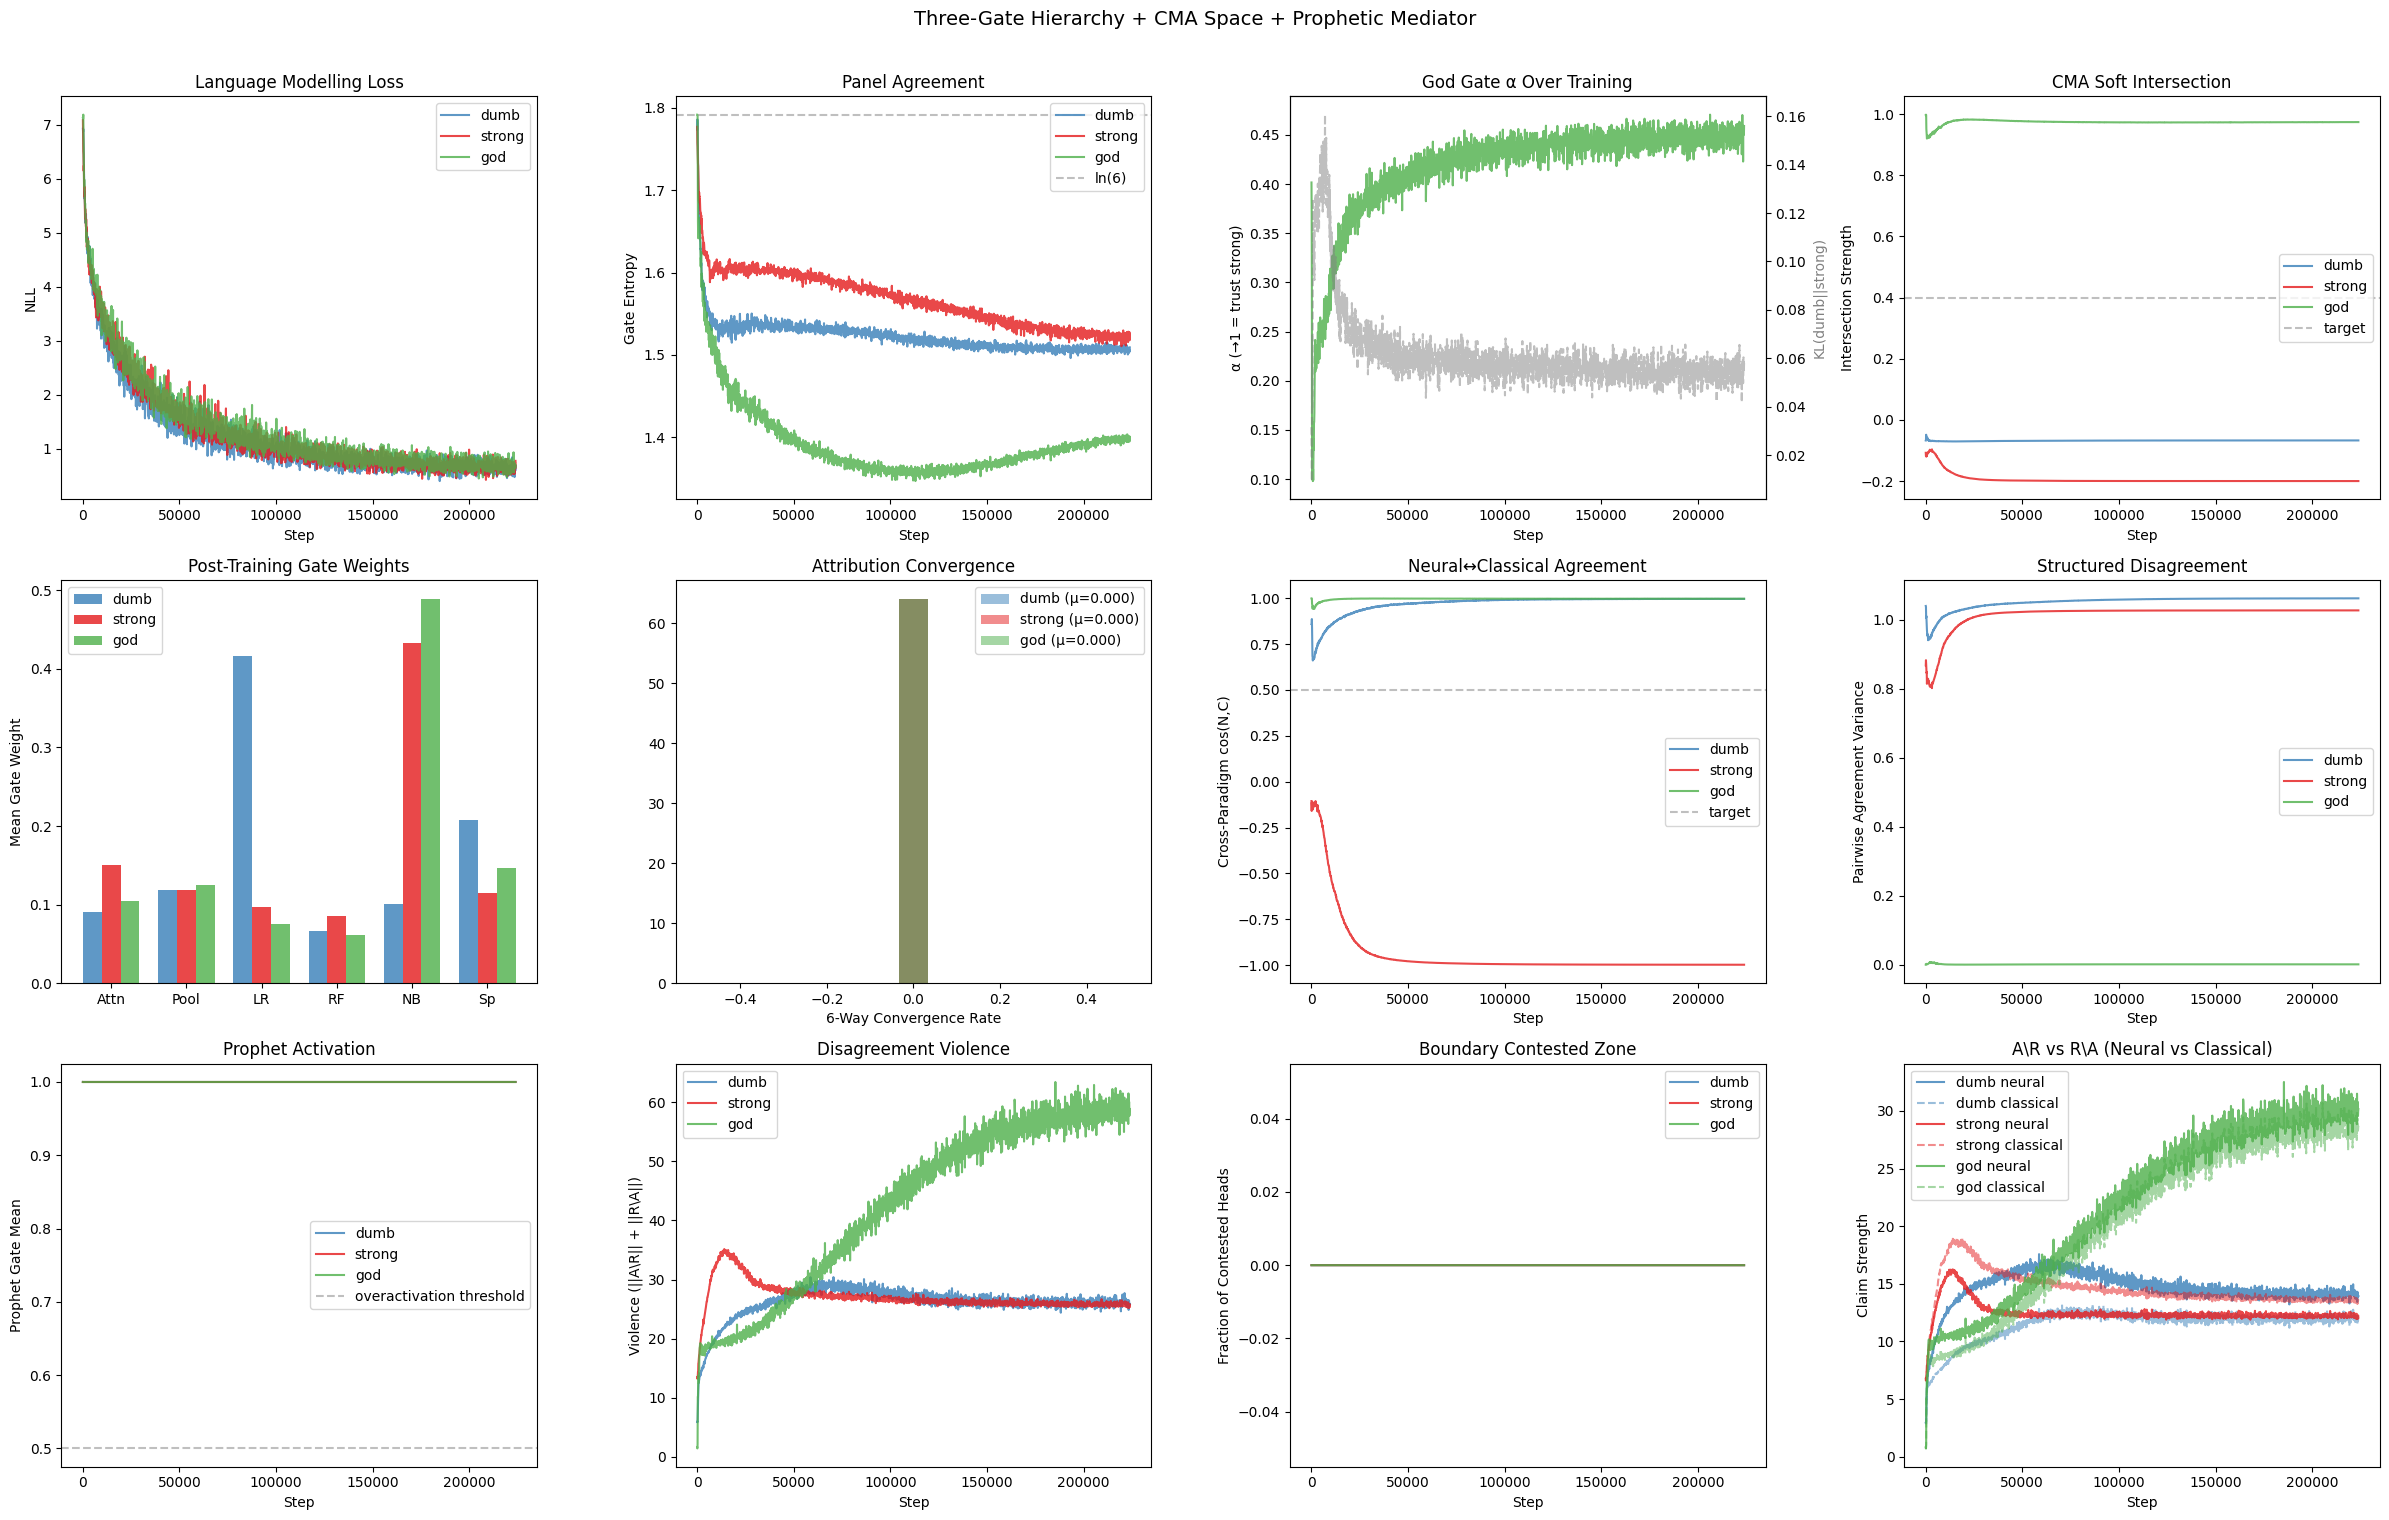

  📊 Plot saved: /content/cma_prophet_comparison.png


In [13]:
# ══════════════════════════════════════════════════════════════════════
# GO
# ══════════════════════════════════════════════════════════════════════

models, logs, tokenizer, decomposer, stats = run_three_gate_experiment(
    n_epochs=2, batch_size=16, lr=3e-4, log_interval=100
)

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Discrete Set Algebra via PolarQuant Bins
# ══════════════════════════════════════════════════════════════════════
#
# Post-hoc analysis: no retraining needed.
#
# For each head, each token gets assigned to angular bins via PolarQuant.
# Two heads "agree" on a token if they assign it to the SAME bin.
# This gives us literal, discrete, countable sets — the crisp version
# of what CMASpace approximates with cosine similarity.
#
# Requires: model, token_ids, tokenizer, device from earlier cells.

import math
import torch
import numpy as np
from collections import defaultdict


def extract_polarquant_bins(model, input_ids, top_k=10):
    """
    For each head, extract the top-K PolarQuant angular bins
    that head assigns to each token position.

    Returns per-head sets of (token_position, bin_id) tuples.
    """
    model.eval()
    device = input_ids.device

    with torch.no_grad():
        # Run backbone
        hidden, _, _ = model._run_backbone(input_ids)

        # Get each head's CMA vector
        polar_feats = model.polar.to_sparse_features(hidden)
        cma1, _, _ = model.head_bilstm_attn(hidden)
        cma2, _, _ = model.head_bilstm_pool(hidden)
        cma3, _, _ = model.head_lr(polar_feats)
        cma4, _, _ = model.head_rf(polar_feats)
        cma5, _, _ = model.head_nb(polar_feats)
        cma6, _, _ = model.head_sparsemax(hidden)

    head_cmas = {
        'bilstm_attn': cma1, 'bilstm_pool': cma2,
        'lr': cma3, 'rf': cma4, 'nb': cma5, 'sparsemax': cma6,
    }

    polar = model.polar  # shared PolarQuantProjection
    n_angles = polar.n_angles
    d_model = polar.d_model
    pk = polar.top_k

    head_bin_sets = {}

    for name, cma_vec in head_cmas.items():
        # Run PolarQuant's rotation + angle extraction on each head's CMA
        with torch.no_grad():
            rotated = torch.matmul(cma_vec, polar.rotation)
            d_pairs = d_model // 2
            pairs = rotated[..., :2 * d_pairs].reshape(
                *cma_vec.shape[:-1], d_pairs, 2)
            radii = torch.norm(pairs, dim=-1)
            angles = torch.atan2(pairs[..., 1], pairs[..., 0])

            # Quantize angles into bins
            angle_bins = ((angles + math.pi) / (2 * math.pi) * n_angles)
            angle_bins = angle_bins.round().long() % n_angles  # [B, S, d_pairs]

            # Top-K by radius (same as PolarQuant)
            top_radii, top_idx = torch.topk(radii, pk, dim=-1)
            top_bins = torch.gather(angle_bins, -1, top_idx)  # [B, S, top_k]

        head_bin_sets[name] = top_bins  # [B, S, top_k] integer bin IDs

    return head_bin_sets


def discrete_set_algebra(head_bin_sets, top_k_positions=20):
    """
    Literal set intersection/difference on PolarQuant bin assignments.

    For each token position, each head has a SET of bin IDs (top-K bins).
    Two heads agree on token t if their bin sets overlap.

    Returns per-batch results with crisp set operations.
    """
    head_names = list(head_bin_sets.keys())
    B, S, K = head_bin_sets[head_names[0]].shape
    neural_names = ['bilstm_attn', 'bilstm_pool', 'sparsemax']
    classical_names = ['lr', 'rf', 'nb']

    results = []

    for b in range(B):
        # Per-token: compute bin set for each head
        token_results = []

        for t in range(S):
            head_sets = {}
            for name in head_names:
                bins = head_bin_sets[name][b, t].cpu().tolist()
                head_sets[name] = set(bins)

            # Full intersection: bins ALL heads agree on
            all_sets = list(head_sets.values())
            full_intersection = set.intersection(*all_sets) if all_sets else set()

            # Neural consensus
            neural_sets = [head_sets[n] for n in neural_names]
            neural_inter = set.intersection(*neural_sets) if neural_sets else set()

            # Classical consensus
            classical_sets = [head_sets[n] for n in classical_names]
            classical_inter = set.intersection(*classical_sets) if classical_sets else set()

            # A ∩ R: bins where neural AND classical consensus overlap
            a_cap_r = neural_inter & classical_inter

            # A \ R: neural consensus bins NOT in classical consensus
            a_minus_r = neural_inter - classical_inter

            # R \ A: classical consensus bins NOT in neural consensus
            r_minus_a = classical_inter - neural_inter

            # Symmetric difference
            a_delta_r = a_minus_r | r_minus_a

            # Union
            union = set().union(*all_sets)

            token_results.append({
                'full_intersection': full_intersection,
                'neural_consensus': neural_inter,
                'classical_consensus': classical_inter,
                'A_cap_R': a_cap_r,
                'A_minus_R': a_minus_r,
                'R_minus_A': r_minus_a,
                'A_delta_R': a_delta_r,
                'union': union,
                'convergence_rate': len(full_intersection) / max(len(union), 1),
                'cross_rate': len(a_cap_r) / max(len(neural_inter | classical_inter), 1),
                'disagreement_size': len(a_delta_r),
            })

        # Aggregate across tokens
        convergences = [tr['convergence_rate'] for tr in token_results]
        cross_rates = [tr['cross_rate'] for tr in token_results]
        disagree_sizes = [tr['disagreement_size'] for tr in token_results]

        # Find tokens with highest disagreement (most interesting for interpretability)
        ranked_by_disagree = sorted(
            range(S), key=lambda t: token_results[t]['disagreement_size'],
            reverse=True)

        results.append({
            'token_results': token_results,
            'mean_convergence': np.mean(convergences),
            'mean_cross_rate': np.mean(cross_rates),
            'mean_disagree_size': np.mean(disagree_sizes),
            'top_disagreement_positions': ranked_by_disagree[:top_k_positions],
        })

    return results


def run_discrete_analysis(model, token_ids, tokenizer, device,
                          n_samples=50, seq_len=256):
    """Run discrete PolarQuant set algebra on sample sequences."""
    print("=" * 70)
    print("DISCRETE SET ALGEBRA — PolarQuant Bin Analysis")
    print("=" * 70)

    dataset = TextDataset(token_ids, seq_len)
    loader = DataLoader(dataset, batch_size=8, shuffle=True)

    all_convergences = []
    all_cross_rates = []
    all_disagree_sizes = []
    example_sequences = []
    count = 0

    model = model.to(device)
    model.eval()

    for inputs, _ in loader:
        if count >= n_samples:
            break
        inputs = inputs.to(device)

        head_bins = extract_polarquant_bins(model, inputs)
        batch_results = discrete_set_algebra(head_bins)

        for br in batch_results:
            all_convergences.append(br['mean_convergence'])
            all_cross_rates.append(br['mean_cross_rate'])
            all_disagree_sizes.append(br['mean_disagree_size'])

        # Save first batch for detailed inspection
        if count == 0:
            example_sequences = batch_results

        count += inputs.size(0)

    model = model.cpu()

    print(f"\nAnalyzed {count} sequences")
    print(f"\nDiscrete Set Algebra (PolarQuant bins):")
    print(f"  6-way bin convergence:   {np.mean(all_convergences):.4f} "
          f"(±{np.std(all_convergences):.4f})")
    print(f"  Cross-paradigm (A∩R):    {np.mean(all_cross_rates):.4f} "
          f"(±{np.std(all_cross_rates):.4f})")
    print(f"  Mean |A△R| (disagree):   {np.mean(all_disagree_sizes):.2f} "
          f"(±{np.std(all_disagree_sizes):.2f})")

    # Show example: decode tokens at highest-disagreement positions
    if example_sequences:
        ex = example_sequences[0]
        print(f"\nExample sequence — top disagreement positions:")
        for pos in ex['top_disagreement_positions'][:10]:
            tr = ex['token_results'][pos]
            print(f"  pos {pos:3d}: "
                  f"|A\\R|={len(tr['A_minus_R']):2d}  "
                  f"|R\\A|={len(tr['R_minus_A']):2d}  "
                  f"|A∩R|={len(tr['A_cap_R']):2d}  "
                  f"|A△R|={len(tr['A_delta_R']):2d}")

    return {
        'convergences': all_convergences,
        'cross_rates': all_cross_rates,
        'disagree_sizes': all_disagree_sizes,
        'examples': example_sequences,
    }


# ── Run on the loaded dumb-gate model ──
# (Run on all_models after cell 15 finishes for the full comparison)

split_idx = int(len(token_ids) * 0.85)
test_ids = token_ids[split_idx:]

discrete_results = run_discrete_analysis(
    model, test_ids, tokenizer, device, n_samples=50)
